# EDA (Phân tích Dữ liệu Khám phá) – Derm7pt cho CBM và ECBM

Phân tích khám phá dữ liệu (Exploratory Data Analysis - EDA) trên bộ dữ liệu `Derm7pt`

### Mục tiêu chuẩn bị cho các mô hình thực nghiệm:
- **M0 Majority Baseline**: Đường cơ sở gán nhãn đa số cho diagnosis và concept.
- **M1 Black-box EfficientNet-B0**: Mô hình học sâu chuẩn end-to-end từ ảnh $X \to Y$.
- **M2 Oracle Concept Classifier**: Mô hình phân loại chẩn đoán từ ground-truth concepts $C \to Y$.
- **M3 Soft Joint CBM**: Concept Bottleneck Model chuẩn với liên kết concept dạng xác suất mềm.
- **M5 ECBM**: Energy-Based Concept Bottleneck Model học phân bố năng lượng chung $E(X, C, Y)$ và khảo sát khả năng mô hình hóa tương tác giữa các concepts.

### Nguyên tắc thực nghiệm cốt lõi:
1. **Bảo toàn dữ liệu gốc:** Không can thiệp, chỉnh sửa hay xóa mẫu trên raw dataset. Các cột dẫn xuất chỉ tồn tại trong manifest/bộ nhớ.
2. **Bảo tồn cấu trúc Concept:** Duy trì biểu diễn ngữ nghĩa $C = (C_1, C_2, \dots, C_7)$ với 7 biến phân loại (categorical variables) và tổng cộng 28 trạng thái (states). Không diễn giải thành 28 nhị phân độc lập.
3. **Kỷ luật phân chia dữ liệu (Data Hygiene):** Chỉ sử dụng tập **TRAIN** cho mọi quyết định mô hình hóa (class weights, candidate loss strategy, xác định ngưỡng hiếm). Tập **VALIDATION** dùng chọn checkpoint/ngưỡng. Tập **TEST** tuyệt đối chỉ dùng cho kiểm toán mô tả (descriptive audit), không dùng để can thiệp thiết kế mô hình hay lựa chọn siêu tham số.

In [22]:
%matplotlib inline

from pathlib import Path
from collections import Counter, defaultdict
import hashlib
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

try:
    from IPython.display import display, Markdown
except ImportError:
    def display(*args, **kwargs):
        for arg in args:
            print(arg)
    class Markdown:
        def __init__(self, text):
            self.text = text
        def __repr__(self):
            return self.text

try:
    import seaborn as sns
except ImportError:
    sns = None

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "font.size": 10,
})

RANDOM_SEED = 42


def find_project_root(start: Path) -> Path:
    # Tự động tìm thư mục gốc dự án KLTN từ vị trí thực thi hiện tại.
    # Hỗ trợ chạy từ workspace root, thư mục KLTN/, hoặc KLTN/Notebooks/.
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "Derm7pt/release_v0/meta/meta.csv").is_file():
            return candidate
        if (candidate / "KLTN/Derm7pt/release_v0/meta/meta.csv").is_file():
            return candidate / "KLTN"
    raise FileNotFoundError(
        "Không tìm thấy thư mục Derm7pt/release_v0/meta/meta.csv từ đường dẫn hiện tại."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
DATASET_ROOT = PROJECT_ROOT / "Derm7pt" / "release_v0"
META_DIR = DATASET_ROOT / "meta"
IMAGE_DIR = DATASET_ROOT / "images"
DATA_DIR = PROJECT_ROOT / "data"

META_PATH = META_DIR / "meta.csv"
SPLIT_PATHS = {
    "train": META_DIR / "train_indexes.csv",
    "valid": META_DIR / "valid_indexes.csv",
    "test": META_DIR / "test_indexes.csv",
}
LABEL_MAPPING_PATH = DATA_DIR / "label_mapping.json"
MANIFEST_PATH = DATA_DIR / "manifest.csv"

CONCEPT_COLUMNS = [
    "pigment_network",
    "streaks",
    "pigmentation",
    "regression_structures",
    "dots_and_globules",
    "blue_whitish_veil",
    "vascular_structures",
]

print(f"Project root       : {PROJECT_ROOT}")
print(f"Metadata file      : {META_PATH}")
print(f"Images directory   : {IMAGE_DIR}")
print(f"Official mapping   : {LABEL_MAPPING_PATH}")

Project root       : /Users/nhathuy/Desktop/HK1_26-27/KLTN/PROJECT
Metadata file      : /Users/nhathuy/Desktop/HK1_26-27/KLTN/PROJECT/Derm7pt/release_v0/meta/meta.csv
Images directory   : /Users/nhathuy/Desktop/HK1_26-27/KLTN/PROJECT/Derm7pt/release_v0/images
Official mapping   : /Users/nhathuy/Desktop/HK1_26-27/KLTN/PROJECT/data/label_mapping.json


## 1. Metadata và Official Split (Phân chia Dữ liệu Chính thức)

Dữ liệu Derm7pt đi kèm official split được công bố trong các file `train_indexes.csv`, `valid_indexes.csv`, `test_indexes.csv`.
Các file này chứa **chỉ số dòng 0-based** của `meta.csv`, không phải `case_num`. Chúng ta bảo toàn cả `source_index` (chỉ số dòng gốc) và `case_num` (mã số ca của bộ dữ liệu) để bảo đảm tính truy vết tuyệt đối.

In [23]:
meta_raw = pd.read_csv(META_PATH)

split_indices = {
    split: pd.read_csv(path)["indexes"].astype(int).tolist()
    for split, path in SPLIT_PATHS.items()
}

index_to_split = {}
for split, indices in split_indices.items():
    for idx in indices:
        index_to_split[idx] = split

data = meta_raw.copy()
data.insert(0, "source_index", np.arange(len(data), dtype=int))
data["split"] = data["source_index"].map(index_to_split)


def diagnosis_to_binary(label: str) -> int:
    # Quy tắc phân loại nhị phân chính thức của đề tài:
    # Mọi chẩn đoán có tiền tố 'melanoma' (không phân biệt chữ hoa/thường) được gán là Melanoma (1).
    # Tất cả các chẩn đoán lành tính hoặc ung thư không phải melanoma khác là Non-Melanoma (0).
    return int(str(label).strip().lower().startswith("melanoma"))


data["diagnosis_binary"] = data["diagnosis"].map(diagnosis_to_binary).astype(int)
data["diagnosis_binary_name"] = data["diagnosis_binary"].map(
    {0: "Non-Melanoma", 1: "Melanoma"}
)

display(data.head(3))
display(Markdown(
    f"**Xác nhận:** Đã đọc thành công `{len(data):,}` dòng và `{meta_raw.shape[1]}` cột metadata gốc. "
    "Toàn bộ các cột `source_index`, `split`, `diagnosis_binary` và `diagnosis_binary_name` là các cột dẫn xuất trong bộ nhớ; "
    "tệp tin `meta.csv` gốc hoàn toàn bất biến."
))

,source_index,case_num,diagnosis,seven_point_score,pigment_network,streaks,pigmentation,regression_structures,dots_and_globules,blue_whitish_veil,vascular_structures,level_of_diagnostic_difficulty,elevation,location,sex,management,clinic,derm,case_id,notes,split,diagnosis_binary,diagnosis_binary_name
0,0,1,basal cell carcinoma,0,absent,absent,absent,absent,absent,absent,arborizing,medium,nodular,abdomen,female,excision,NEL/NEL025.JPG,NEL/Nel026.jpg,NaN,NaN,train,0,Non-Melanoma
1,1,2,basal cell carcinoma,1,absent,absent,absent,absent,irregular,absent,absent,low,palpable,head neck,female,excision,NEL/NEL027.JPG,NEL/Nel028.jpg,NaN,NaN,valid,0,Non-Melanoma
2,2,3,basal cell carcinoma,1,absent,absent,absent,absent,irregular,absent,arborizing,medium,palpable,head neck,female,excision,NEL/Nel032.jpg,NEL/Nel033.jpg,NaN,NaN,train,0,Non-Melanoma


**Xác nhận:** Đã đọc thành công `1,011` dòng và `19` cột metadata gốc. Toàn bộ các cột `source_index`, `split`, `diagnosis_binary` và `diagnosis_binary_name` là các cột dẫn xuất trong bộ nhớ; tệp tin `meta.csv` gốc hoàn toàn bất biến.

## 2. Kiểm toán Tính toàn vẹn Dữ liệu và Rò rỉ Dữ liệu (Data Integrity & Leakage Audit)

Tại phần này, chúng ta tiến hành kiểm toán hệ thống về:
1. **Giao thoa chỉ số split:** Đảm bảo không có trường hợp nào xuất hiện đồng thời ở nhiều tập phân chia.
2. **Sự tồn tại của ảnh và tính nhạy chữ hoa/thường:** Kiểm tra đường dẫn vật lý trên đĩa.
3. **Phát hiện trùng lặp file tuyệt đối bằng MD5 Hash:** Kiểm tra có exact file duplicate hoặc exact cross-split hash collision hay không.
4. **Kiểm toán định danh bệnh nhân (Patient-level Leakage Audit):** Đánh giá mức độ khả thi của việc kiểm chứng rò rỉ cấp bệnh nhân từ trường `case_id` trong metadata.

In [24]:
all_split_indices = [idx for indices in split_indices.values() for idx in indices]
expected_indices = set(range(len(data)))

split_overlap = {
    "train ∩ valid": len(set(split_indices["train"]) & set(split_indices["valid"])),
    "train ∩ test": len(set(split_indices["train"]) & set(split_indices["test"])),
    "valid ∩ test": len(set(split_indices["valid"]) & set(split_indices["test"])),
}

integrity_rows = [
    ("Số trường hợp metadata", len(data), "1.011 ca"),
    ("Số case_num duy nhất", data["case_num"].nunique(), "1.011 ca (duy nhất 100%)"),
    ("Tổng chỉ số phân chia", len(all_split_indices), "1.011 chỉ số"),
    ("Chỉ số nằm ngoài [0, 1010]", len(set(all_split_indices) - expected_indices), "0 chỉ số"),
    ("Chỉ số bị bỏ sót", len(expected_indices - set(all_split_indices)), "0 chỉ số"),
    ("Trùng lặp train ∩ valid", split_overlap["train ∩ valid"], "0 ca"),
    ("Trùng lặp train ∩ test", split_overlap["train ∩ test"], "0 ca"),
    ("Trùng lặp valid ∩ test", split_overlap["valid ∩ test"], "0 ca"),
]
display(pd.DataFrame(integrity_rows, columns=["Chỉ số kiểm tra", "Thực tế", "Kỳ vọng"]))

,Chỉ số kiểm tra,Thực tế,Kỳ vọng
0,Số trường hợp metadata,1011,1.011 ca
1,Số case_num duy nhất,1011,1.011 ca (duy nhất 100%)
2,Tổng chỉ số phân chia,1011,1.011 chỉ số
3,"Chỉ số nằm ngoài [0, 1010]",0,0 chỉ số
4,Chỉ số bị bỏ sót,0,0 chỉ số
5,Trùng lặp train ∩ valid,0,0 ca
6,Trùng lặp train ∩ test,0,0 ca
7,Trùng lặp valid ∩ test,0,0 ca


In [25]:
_directory_cache = {}


def directory_entries(path: Path):
    key = str(path.resolve())
    if key not in _directory_cache:
        _directory_cache[key] = {entry.name: entry for entry in path.iterdir()}
    return _directory_cache[key]


def resolve_with_exact_case(base: Path, relative_path: str):
    # Tìm file trên hệ thống tệp và phát hiện sai lệch hoa/thường (case mismatch).
    current = base
    mismatches = []
    for part in Path(relative_path).parts:
        entries = directory_entries(current)
        if part in entries:
            current = entries[part]
            continue
        lowered = {name.lower(): name for name in entries}
        if part.lower() in lowered:
            actual_name = lowered[part.lower()]
            mismatches.append((part, actual_name))
            current = entries[actual_name]
        else:
            raise FileNotFoundError(f"Không tìm thấy '{part}' trong '{current}'.")
    return current, mismatches


resolved_derm_paths = []
case_mismatches = []
for row in data.itertuples(index=False):
    resolved_path, mismatch = resolve_with_exact_case(IMAGE_DIR, row.derm)
    resolved_derm_paths.append(str(resolved_path))
    if mismatch:
        case_mismatches.append((row.case_num, row.derm, mismatch))

data["derm_path_resolved"] = resolved_derm_paths

# Tính MD5 Hash cho toàn bộ 1.011 ảnh dermoscopy để kiểm tra exact file duplicates
image_hashes = []
for p in resolved_derm_paths:
    with open(p, "rb") as f:
        image_hashes.append(hashlib.md5(f.read()).hexdigest())

data["image_md5"] = image_hashes

# Kiểm tra exact duplicates trên toàn bộ dataset và cross-split
hash_counts = data["image_md5"].value_counts()
duplicate_hashes = hash_counts[hash_counts > 1]

cross_split_duplicates = (
    data.groupby("image_md5")["split"].nunique()
)
cross_split_leakage = cross_split_duplicates[cross_split_duplicates > 1]

print(f"Tổng số ảnh dermoscopy đã đọc và hash MD5: {len(data)}")
print(f"Số lượng exact file duplicates theo MD5     : {len(duplicate_hashes)}")
print(f"Số lượng exact cross-split hash collisions : {len(cross_split_leakage)}")
if case_mismatches:
    print(f"Phát hiện {len(case_mismatches)} trường hợp lệch chữ hoa/thường: {case_mismatches}")
    print("→ Đã khắc phục tự động trong cột derm_path_resolved của manifest mà không sửa file gốc.")

# Kiểm toán trường case_id (Patient-level identifier)
valid_case_id_count = int(data["case_id"].notna().sum())
print(f"\nKiểm toán trường case_id trong metadata:")
print(f"- Số dòng có case_id: {valid_case_id_count} / {len(data)} ({valid_case_id_count / len(data) * 100:.2f}%)")
print(f"- Số dòng bị khuyết (NaN): {len(data) - valid_case_id_count} / {len(data)} ({(1 - valid_case_id_count / len(data)) * 100:.2f}%)")

Tổng số ảnh dermoscopy đã đọc và hash MD5: 1011
Số lượng exact file duplicates theo MD5     : 0
Số lượng exact cross-split hash collisions : 0
Phát hiện 1 trường hợp lệch chữ hoa/thường: [(816, 'FCl/Fcl068.jpg', [('FCl', 'FCL')])]
→ Đã khắc phục tự động trong cột derm_path_resolved của manifest mà không sửa file gốc.

Kiểm toán trường case_id trong metadata:
- Số dòng có case_id: 27 / 1011 (2.67%)
- Số dòng bị khuyết (NaN): 984 / 1011 (97.33%)


## **Note**
> **Nhận xét Kiểm toán Dữ liệu và Rò rỉ:**
> 1. **Tính toàn vẹn tệp tin:** Bộ dữ liệu có đủ $1.011$ ca, $1.011$ file ảnh tồn tại trên đĩa và đọc được bình thường. Không có ảnh nào bị hỏng (corrupted).
> 2. **Kiểm toán trùng lặp cấp tệp (Image/File-level Leakage):** Không phát hiện exact file duplicates theo MD5 và không phát hiện exact cross-split hash collisions ($0$ trường hợp). Lưu ý rằng kiểm tra MD5 chỉ xác nhận không có file trùng lặp byte tuyệt đối, không suy diễn rằng đã loại trừ được near-duplicates, ảnh bị thay đổi độ phân giải (resized) hoặc ảnh được mã hóa lại (re-encoded).
> 3. **Lệch chữ hoa/thường (Case mismatch):** Có đúng $1$ trường hợp (ca 816, `images/FCl/Fcl068.jpg` so với thư mục thực tế `images/FCL/Fcl068.jpg`). Lỗi này được chuẩn hóa tự động trong manifest, giữ nguyên raw dataset.
> 4. **Kiểm toán cấp bệnh nhân (Patient-level Leakage Audit):** Do trường `case_id` bị thiếu ở phần lớn số mẫu (khuyết khoảng $97.33\%$, tương ứng $984/1011$ dòng NaN), **patient-level leakage không thể được kiểm chứng độc lập từ metadata hiện có**. Nghiên cứu giữ nguyên official train/validation/test indices do Derm7pt cung cấp và không thực hiện reshuffling.

## 3. Phân bố Diagnosis (chẩn đoán) và Ánh xạ Nhị phân (Melanoma vs Non-Melanoma)

Đề tài tập trung vào bài toán phân loại nhị phân cốt lõi: **Melanoma (1)** so với **Non-Melanoma (0)**.
Phần này kiểm tra chi tiết:
- Phân bổ số lượng ca và tỷ lệ dương tính theo từng split.
- Bảng ánh xạ 20 chẩn đoán lâm sàng gốc sang nhãn nhị phân.
- Ghi nhận trường hợp `melanoma metastasis` và nhãn `melanoma` đơn lẻ.

,Total,Melanoma,Non-Melanoma,Melanoma Rate (%)
split,,,,
train,413,90,323,21.7918
valid,203,61,142,30.0493
test,395,101,294,25.5696


Imbalance ratio trên tập TRAIN (Non-Melanoma : Melanoma) = 3.59 : 1
→ Class weighting / weighted loss là candidate strategy dựa trên TRAIN distribution (tỷ lệ Non-Mel : Mel ≈ 3.59 : 1); việc sử dụng cuối cùng phải được xác nhận bằng validation performance.


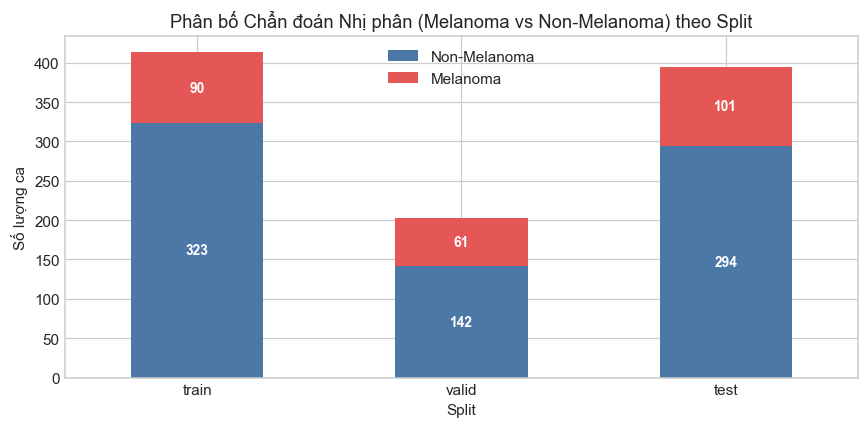

In [26]:
split_order = ["train", "valid", "test"]

split_summary = (
    data.groupby("split", observed=True)["diagnosis_binary"]
    .agg(Total="size", Melanoma="sum")
    .reindex(split_order)
)
split_summary["Non-Melanoma"] = split_summary["Total"] - split_summary["Melanoma"]
split_summary["Melanoma Rate (%)"] = (split_summary["Melanoma"] / split_summary["Total"]) * 100
display(split_summary)

train_imbalance_ratio = split_summary.loc["train", "Non-Melanoma"] / split_summary.loc["train", "Melanoma"]
print(f"Imbalance ratio trên tập TRAIN (Non-Melanoma : Melanoma) = {train_imbalance_ratio:.2f} : 1")
print(f"→ Class weighting / weighted loss là candidate strategy dựa trên TRAIN distribution (tỷ lệ Non-Mel : Mel ≈ {train_imbalance_ratio:.2f} : 1); việc sử dụng cuối cùng phải được xác nhận bằng validation performance.")

ax = split_summary[["Non-Melanoma", "Melanoma"]].plot(
    kind="bar", stacked=True, color=["#4C78A8", "#E45756"], figsize=(8, 4)
)
ax.set_title("Phân bố Chẩn đoán Nhị phân (Melanoma vs Non-Melanoma) theo Split")
ax.set_xlabel("Split")
ax.set_ylabel("Số lượng ca")
ax.tick_params(axis="x", rotation=0)
for container in ax.containers:
    ax.bar_label(container, label_type="center", color="white", fontsize=9, weight="bold")
plt.tight_layout()
plt.show()

split,Raw Diagnosis,diagnosis_binary,binary_name,train,valid,test,Total
11,melanoma (less than 0.76 mm),1,Melanoma,39,23,40,102
10,melanoma (in situ),1,Melanoma,22,16,26,64
9,melanoma (0.76 to 1.5 mm),1,Melanoma,21,14,18,53
12,melanoma (more than 1.5 mm),1,Melanoma,6,7,15,28
13,melanoma metastasis,1,Melanoma,2,1,1,4
8,melanoma,1,Melanoma,0,0,1,1
2,clark nevus,0,Non-Melanoma,176,67,156,399
17,reed or spitz nevus,0,Non-Melanoma,27,18,34,79
18,seborrheic keratosis,0,Non-Melanoma,16,10,19,45
0,basal cell carcinoma,0,Non-Melanoma,19,7,16,42


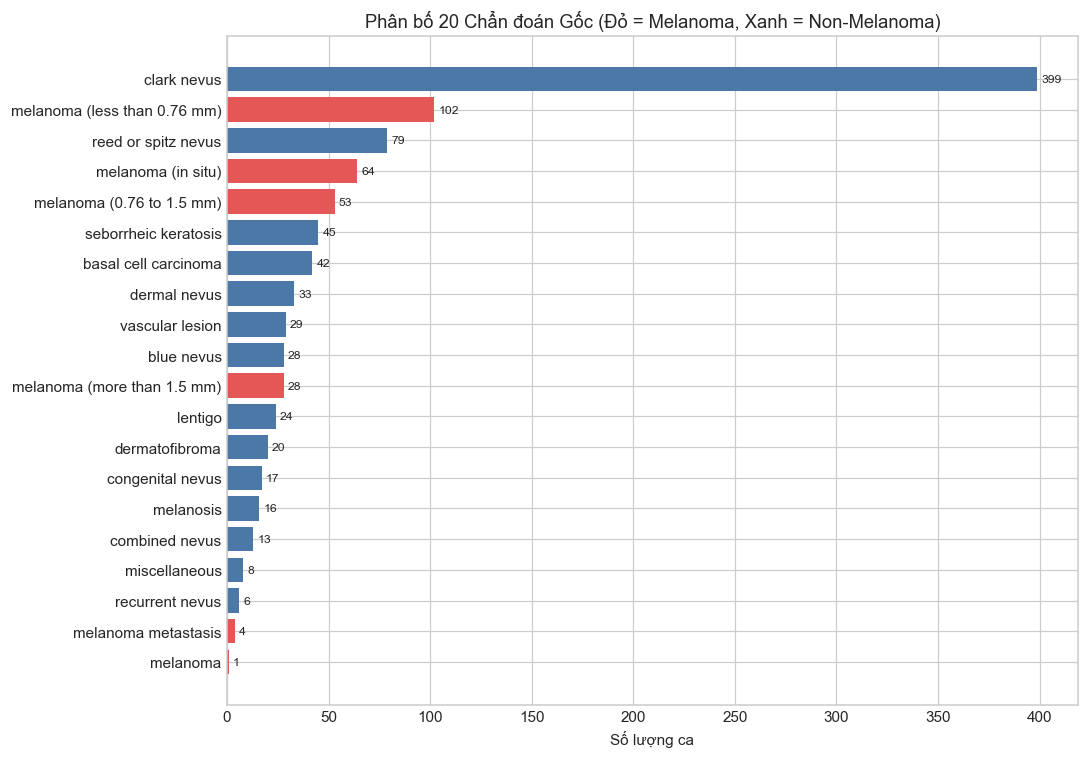

In [27]:
raw_diag_crosstab = (
    pd.crosstab(data["diagnosis"], data["split"])
    .reindex(columns=split_order, fill_value=0)
)
raw_diag_crosstab["total"] = raw_diag_crosstab.sum(axis=1)
raw_diag_crosstab["diagnosis_binary"] = [
    diagnosis_to_binary(d) for d in raw_diag_crosstab.index
]
raw_diag_crosstab["binary_name"] = raw_diag_crosstab["diagnosis_binary"].map(
    {0: "Non-Melanoma", 1: "Melanoma"}
)

raw_diag_table = (
    raw_diag_crosstab.reset_index()
    .sort_values(by=["diagnosis_binary", "total"], ascending=[False, False])
    .rename(columns={"diagnosis": "Raw Diagnosis", "total": "Total"})
    [["Raw Diagnosis", "diagnosis_binary", "binary_name", "train", "valid", "test", "Total"]]
)

display(raw_diag_table)

# Trực quan hóa 20 loại tổn thương gốc
fig, ax = plt.subplots(figsize=(10, 7))
plot_df = raw_diag_table.sort_values("Total", ascending=True)
colors = ["#E45756" if b == 1 else "#4C78A8" for b in plot_df["diagnosis_binary"]]
bars = ax.barh(plot_df["Raw Diagnosis"], plot_df["Total"], color=colors)
ax.set_title("Phân bố 20 Chẩn đoán Gốc (Đỏ = Melanoma, Xanh = Non-Melanoma)")
ax.set_xlabel("Số lượng ca")
for bar, total in zip(bars, plot_df["Total"]):
    ax.text(total + 2, bar.get_y() + bar.get_height() / 2, str(int(total)), va="center", fontsize=8)
plt.tight_layout()
plt.show()

> **Quy ước Ánh xạ Chẩn đoán (Diagnosis Mapping Convention):**
> 1. **Quy tắc phân loại:** Tất cả các ca có nhãn chẩn đoán bắt đầu bằng `"melanoma"` được gán nhãn dương tính ($y = 1$). Quy tắc này đã được đóng băng (frozen) cho toàn bộ chuỗi thực nghiệm.
> 2. **Trường hợp `melanoma metastasis` (Di căn hắc tố):** Có $4$ ca ($2$ train, $1$ valid, $1$ test) được ánh xạ vào nhóm Melanoma ($y = 1$) theo định nghĩa nhãn nhị phân thao tác (*operational binary label definition*) của nghiên cứu. Đây là quy ước kỹ thuật để phân định tổn thương ác tính dòng tế bào hắc tố, không tuyên bố rằng di căn melanoma và melanoma nguyên phát là cùng một thực thể bệnh học lâm sàng.
> 3. **Nhãn `melanoma` đơn lẻ:** Có duy nhất $1$ ca chẩn đoán là `melanoma` không kèm độ sâu Breslow (nằm trong tập test).
> 4. **Mất cân bằng lớp (Class Imbalance):** Tập train có $90$ ca Melanoma trên tổng số $413$ ca ($21.79\%$), tỷ lệ mất cân bằng là $\approx 3.59 : 1$. Class weighting / weighted loss là candidate strategy dựa trên TRAIN distribution; việc sử dụng cuối cùng phải được xác nhận bằng validation performance. Mọi class weight chỉ được tính từ TRAIN; TEST tuyệt đối không được dùng để quyết định loss hoặc class weights.

## 4. Cấu trúc 7 Categorical Concepts và 28 Trạng thái

Hệ thống 7 tiêu chí Derm7pt mô tả các đặc điểm cấu trúc hiển vi bề mặt da (dermoscopic criteria).
Phần này xác nhận:
1. **Semantic representation:** $C = (C_1, C_2, \dots, C_7)$ gồm đúng 7 biến phân loại (categorical variables), mỗi concept có không gian trạng thái phân loại riêng, tương ứng với số trạng thái:
   $$\text{Head sizes} = [3, 3, 5, 4, 3, 2, 8] \implies \sum_{i=1}^7 K_i = 28 \text{ states}$$
2. **Authoritative mapping:** Kiểm tra mapping với `data/label_mapping.json`.
3. **Phát hiện tự động trạng thái hiếm và unseen:** Làm nổi bật trạng thái `pigmentation = localized regular` ($0$ train, $0$ val, $3$ test).
4. **Chuẩn bị Metrics đánh giá Concept:** Thiết lập framework đo lường chuẩn theo từng concept cho các mô hình CBM/ECBM về sau.

In [28]:
with open(LABEL_MAPPING_PATH, "r", encoding="utf-8") as f:
    official_label_mapping = json.load(f)

concept_verification_records = []
total_states_count = 0

for concept in CONCEPT_COLUMNS:
    mapping_states = official_label_mapping[concept]
    meta_states = set(data[concept].dropna().unique())
    num_states = len(mapping_states)
    total_states_count += num_states
    
    # 1. Kiểm tra mapping integer ID liên tục từ 0 đến K-1
    expected_ids = set(range(num_states))
    actual_ids = set(mapping_states.values())
    id_continuous = (expected_ids == actual_ids)
    
    # 2. Kiểm tra không có trạng thái ngoài mapping
    no_unknown_states = (meta_states == set(mapping_states.keys()))
    
    # 3. Kiểm tra Encode -> Decode lossless
    encoded = data[concept].map(mapping_states)
    id_to_state = {v: k for k, v in mapping_states.items()}
    decoded = encoded.map(id_to_state)
    is_lossless = (decoded == data[concept]).all()
    
    concept_verification_records.append({
        "Concept": concept,
        "Số states (K_i)": num_states,
        "States": list(mapping_states.keys()),
        "Continuous IDs [0, K-1]": id_continuous,
        "Không có unknown state": no_unknown_states,
        "Encode-Decode Lossless": is_lossless,
    })

concept_verification_df = pd.DataFrame(concept_verification_records)
display(concept_verification_df[["Concept", "Số states (K_i)", "Continuous IDs [0, K-1]", "Không có unknown state", "Encode-Decode Lossless"]])

print(f"Tổng số concept categorical: {len(CONCEPT_COLUMNS)}")
print(f"Tổng số concept states     : {total_states_count}")
print(f"Kích thước categorical heads: {[len(official_label_mapping[c]) for c in CONCEPT_COLUMNS]}")


,Concept,Số states (K_i),"Continuous IDs [0, K-1]",Không có unknown state,Encode-Decode Lossless
0,pigment_network,3,True,True,True
1,streaks,3,True,True,True
2,pigmentation,5,True,True,True
3,regression_structures,4,True,True,True
4,dots_and_globules,3,True,True,True
5,blue_whitish_veil,2,True,True,True
6,vascular_structures,8,True,True,True


Tổng số concept categorical: 7
Tổng số concept states     : 28
Kích thước categorical heads: [3, 3, 5, 4, 3, 2, 8]


### Xác nhận cấu trúc Concept

Tất cả **7 dermoscopic concepts** đều được biểu diễn dưới dạng **categorical concepts**, với mapping trạng thái được xác định rõ ràng. Không có unknown state trong toàn bộ dữ liệu và quá trình encode–decode có thể khôi phục nguyên trạng các giá trị concept.

- **M2 – Oracle Concept Classifier:** sử dụng trực tiếp **ground-truth concepts** đã encode làm input: $$C_{\text{GT}} = (C_1, C_2, \dots, C_7) \rightarrow Y.$$ M2 **không nhận ảnh** để dự đoán concept, **không có concept prediction head**, và **không tạo ra** $\hat{C}$. Bộ phân loại diagnosis của M2 có thể là Logistic Regression và/hoặc một MLP nhỏ. Mục tiêu của M2 là đánh giá **concept sufficiency**: nếu biết chính xác 7 concepts thì có thể dự đoán diagnosis tốt đến mức nào.

- **M3 – Soft Joint CBM:** mới có luồng đầy đủ: $$X \rightarrow \hat{C} \rightarrow \hat{Y}.$$ Concept predictor của M3 gồm **7 categorical softmax heads riêng biệt**, mỗi head dùng softmax trên $K_i$ trạng thái của concept $C_i$, với kích thước các heads là $[3, 3, 5, 4, 3, 2, 8]$. Không biểu diễn 28 states thành 28 biến nhị phân sigmoid độc lập nhằm bảo toàn tính loại trừ lẫn nhau giữa các trạng thái thuộc cùng một concept.

- **M5 – ECBM:** tiếp tục bảo toàn cấu trúc semantic gồm 7 categorical concept groups. Cách parameterization và inference cho các categorical concepts sẽ được xác định riêng trong giai đoạn adaptation ECBM.

Do đó, representation của concept được hiểu là:

$$C=(C_1,C_2,\dots,C_7)$$

với mỗi $C_i$ là một biến categorical, thay vì xem toàn bộ hệ thống như một bài toán multi-label gồm 28 biến nhị phân độc lập.

In [29]:
RARE_THRESHOLD = 10  # Ngưỡng mô tả (descriptive threshold) cho trạng thái hiếm trong tập train

state_analysis_rows = []
for concept in CONCEPT_COLUMNS:
    state_map = official_label_mapping[concept]
    for state, code_id in state_map.items():
        subset_all = data[data[concept] == state]
        subset_tr = subset_all[subset_all["split"] == "train"]
        subset_va = subset_all[subset_all["split"] == "valid"]
        subset_te = subset_all[subset_all["split"] == "test"]
        
        sup_tr = len(subset_tr)
        mel_tr = int(subset_tr["diagnosis_binary"].sum())
        rate_tr = (mel_tr / sup_tr) if sup_tr > 0 else np.nan
        
        sup_va = len(subset_va)
        sup_te = len(subset_te)
        sup_all = len(subset_all)
        mel_all = int(subset_all["diagnosis_binary"].sum())
        rate_all = (mel_all / sup_all) if sup_all > 0 else np.nan
        
        # Phân loại trạng thái tự động
        if sup_tr == 0:
            status = "unseen_in_train"
        elif sup_tr < RARE_THRESHOLD:
            status = "rare_in_train"
        elif (sup_va + sup_te) == 0:
            status = "absent_outside_train"
        else:
            status = "normal"
            
        state_analysis_rows.append({
            "concept": concept,
            "state": state,
            "code": code_id,
            "train_count": sup_tr,
            "val_count": sup_va,
            "test_count": sup_te,
            "support_train": sup_tr,
            "melanoma_count_train": mel_tr,
            "melanoma_rate_train": rate_tr,
            "support_all": sup_all,
            "melanoma_count_all": mel_all,
            "melanoma_rate_all": rate_all,
            "status": status,
        })

concept_states_df = pd.DataFrame(state_analysis_rows)

# Bảng các trạng thái đặc biệt (unseen hoặc rare)
special_states_df = concept_states_df[concept_states_df["status"] != "normal"][
    ["concept", "state", "code", "train_count", "val_count", "test_count", "support_all", "melanoma_rate_train", "melanoma_rate_all", "status"]
]
print("BẢNG CÁC TRẠNG THÁI HIẾM HOẶC CHƯA TỪNG XUẤT HIỆN TRONG TRAIN (UNSEEN / RARE STATES):")
display(special_states_df)

BẢNG CÁC TRẠNG THÁI HIẾM HOẶC CHƯA TỪNG XUẤT HIỆN TRONG TRAIN (UNSEEN / RARE STATES):


,concept,state,code,train_count,val_count,test_count,support_all,melanoma_rate_train,melanoma_rate_all,status
10,pigmentation,localized regular,4,0,0,3,3,NaN,0.3333,unseen_in_train
22,vascular_structures,comma,2,8,4,11,23,0.0000,0.0000,rare_in_train
24,vascular_structures,hairpin,4,4,3,8,15,0.2500,0.2667,rare_in_train
25,vascular_structures,linear irregular,5,5,5,8,18,1.0000,0.9444,rare_in_train
27,vascular_structures,wreath,7,1,1,0,2,0.0000,0.0000,rare_in_train


In [30]:
from sklearn.metrics import precision_recall_fscore_support

def evaluate_concept_predictions(y_true_dict, y_pred_dict, label_mapping, train_observed_states=None):
    # Framework mẫu cho việc đánh giá concept predictor sau này (M0, M2, M3, M5).
    
    # CÁCH TÍNH MACRO-F1 (bắt buộc theo đề tài):
    # - Bước 1: Với mỗi concept C_i (i = 1..7), tính F1 cho từng state k:
    #     F1(C_i, k) = 2 * P(C_i, k) * R(C_i, k) / (P(C_i, k) + R(C_i, k))
    # - Bước 2: Lấy trung bình không trọng số trên K_i states để được Macro-F1(C_i):
    #     Macro-F1(C_i) = (1/K_i) * sum_k F1(C_i, k)
    # - Bước 3: Lấy trung bình trên 7 concepts để được Overall Concept Macro-F1:
    #     Overall Macro-F1 = (1/7) * sum_{i=1}^{7} Macro-F1(C_i)
    #
    # TUYỆT ĐỐI KHÔNG flatten 28 states thành một bài toán classification đơn (28-class) để tính Macro-F1.
    # Con số 28 (all-defined) và 27 (train-observed) là TỔNG số categorical states trên 7 concepts.
    # Macro-F1 PHẢI tính RIÊNG trên state space của từng concept C_i, sau đó lấy mean qua 7 concepts.
    # Mỗi concept C_i có không gian phân loại riêng; metrics phải tính RIÊNG cho từng concept.
    results = {}
    for concept, mapping in label_mapping.items():
        all_labels = sorted(list(mapping.values()))
        all_names = sorted(list(mapping.keys()), key=lambda k: mapping[k])
        
        y_t = y_true_dict[concept]
        y_p = y_pred_dict[concept]
        
        acc = accuracy_score(y_t, y_p)

        # Macro-F1 tính riêng cho concept này trên toàn bộ K_i defined states
        mf1_all = f1_score(y_t, y_p, labels=all_labels, average="macro", zero_division=0)
        
        # Macro-F1 chỉ trên các states có mặt trong tập train
        if train_observed_states and concept in train_observed_states:
            obs_labels = train_observed_states[concept]
            mf1_obs = f1_score(y_t, y_p, labels=obs_labels, average="macro", zero_division=0)
        else:
            mf1_obs = mf1_all

        # Per-state metrics: Precision, Recall, F1, Support cho từng state của concept này
        # Dùng precision_recall_fscore_support để lấy đồng thời cả 4 chỉ số
        p_per, r_per, f1_per, sup_per = precision_recall_fscore_support(
            y_t, y_p, labels=all_labels, average=None, zero_division=0
        )
        cm = confusion_matrix(y_t, y_p, labels=all_labels)
        
        results[concept] = {
            "accuracy": acc,
            "macro_f1_all_defined": mf1_all,
            "macro_f1_train_observed": mf1_obs,
            "n_defined_states": len(all_labels),
            "n_observed_states": len(train_observed_states[concept]) if train_observed_states else len(all_labels),
            "per_state_metrics": pd.DataFrame({
                "concept": concept,
                "state": all_names,
                "code": all_labels,
                "precision": p_per,
                "recall": r_per,
                "f1": f1_per,
                "support": sup_per.astype(int),
            }),
            "confusion_matrix": cm,
        }
    return results


# Xác định danh sách các states thực tế xuất hiện trong tập Train
train_observed_states = {}
for concept in CONCEPT_COLUMNS:
    observed_in_tr = data.loc[data["split"] == "train", concept].dropna().unique()
    train_observed_states[concept] = sorted([official_label_mapping[concept][s] for s in observed_in_tr])

# Minh họa đánh giá Majority Baseline (M0) cho từng concept và tổng hợp Macro-F1
m0_rows = []
for concept in CONCEPT_COLUMNS:
    train_mode_state = data.loc[data["split"] == "train", concept].mode().iloc[0]
    train_mode_id = official_label_mapping[concept][train_mode_state]
    
    n_defined = len(official_label_mapping[concept])
    n_observed = len(train_observed_states[concept])
    
    row = {
        "concept": concept,
        "n_states (all/obs)": f"{n_defined}/{n_observed}",
        "majority_state": train_mode_state,
    }
    for split in split_order:
        sub = data[data["split"] == split]
        y_true = sub[concept].map(official_label_mapping[concept]).tolist()
        y_pred = [train_mode_id] * len(sub)
        
        all_ids = sorted(list(official_label_mapping[concept].values()))
        obs_ids = train_observed_states[concept]
        
        acc = accuracy_score(y_true, y_pred)
        mf1_all = f1_score(y_true, y_pred, labels=all_ids, average="macro", zero_division=0)
        mf1_obs = f1_score(y_true, y_pred, labels=obs_ids, average="macro", zero_division=0)
        
        row[f"{split}_acc"] = acc
        row[f"{split}_mf1_all"] = mf1_all
        row[f"{split}_mf1_obs"] = mf1_obs
        
    m0_rows.append(row)

m0_benchmark_df = pd.DataFrame(m0_rows)

# Tính dòng tổng hợp Overall Concept Macro-F1 (Mean across 7 concepts)
overall_summary = {
    "concept": "OVERALL (Mean across 7 concepts)",
    "n_states (all/obs)": "28/27",
    "majority_state": "-",
    "train_acc": m0_benchmark_df["train_acc"].mean(),
    "train_mf1_all": m0_benchmark_df["train_mf1_all"].mean(),
    "train_mf1_obs": m0_benchmark_df["train_mf1_obs"].mean(),
    "valid_acc": m0_benchmark_df["valid_acc"].mean(),
    "valid_mf1_all": m0_benchmark_df["valid_mf1_all"].mean(),
    "valid_mf1_obs": m0_benchmark_df["valid_mf1_obs"].mean(),
    "test_acc": m0_benchmark_df["test_acc"].mean(),
    "test_mf1_all": m0_benchmark_df["test_mf1_all"].mean(),
    "test_mf1_obs": m0_benchmark_df["test_mf1_obs"].mean(),
}
m0_full_display = pd.concat([m0_benchmark_df, pd.DataFrame([overall_summary])], ignore_index=True)

print("KẾT QUẢ ĐÁNH GIÁ CONCEPT PREDICTOR VỚI M0-C (PER-CONCEPT MAJORITY BASELINES):")
print("Lưu ý: M0-C = Per-Concept Majority Baselines — với mỗi concept C_i, majority state xác định CHỈ từ TRAIN.")
print("Macro-F1 tính riêng trên state space của từng C_i (F1_macro(C_i)), sau đó lấy mean qua 7 concepts.")
print("Con số 28 (all-defined) / 27 (train-observed) là TỔNG categorical states trên 7 concepts — không phải 28-class hay 27-class classification.")
display(m0_full_display[["concept", "n_states (all/obs)", "majority_state", "train_acc", "train_mf1_all", "test_acc", "test_mf1_all", "test_mf1_obs"]])

KẾT QUẢ ĐÁNH GIÁ CONCEPT PREDICTOR VỚI M0-C (PER-CONCEPT MAJORITY BASELINES):
Lưu ý: M0-C = Per-Concept Majority Baselines — với mỗi concept C_i, majority state xác định CHỈ từ TRAIN.
Macro-F1 tính riêng trên state space của từng C_i (F1_macro(C_i)), sau đó lấy mean qua 7 concepts.
Con số 28 (all-defined) / 27 (train-observed) là TỔNG categorical states trên 7 concepts — không phải 28-class hay 27-class classification.


,concept,n_states (all/obs),majority_state,train_acc,train_mf1_all,test_acc,test_mf1_all,test_mf1_obs
0,pigment_network,3/3,absent,0.3874,0.1862,0.3949,0.1887,0.1887
1,streaks,3/3,absent,0.6610,0.2653,0.6506,0.2628,0.2628
2,pigmentation,5/4,absent,0.6126,0.1520,0.5646,0.1443,0.1804
3,regression_structures,4/4,absent,0.7676,0.2171,0.7316,0.2113,0.2113
4,dots_and_globules,3/3,irregular,0.4189,0.1968,0.4481,0.2063,0.2063
5,blue_whitish_veil,2/2,absent,0.8208,0.4508,0.8101,0.4476,0.4476
6,vascular_structures,8/8,absent,0.8402,0.1141,0.7924,0.1105,0.1105
7,OVERALL (Mean across 7 concepts),28/27,-,0.6441,0.2260,0.6275,0.2245,0.2297



> **Nhận xét Cốt lõi về Trạng thái Concept và Chuẩn mực Đánh giá:**
> 1. **Phát hiện trạng thái Unseen trong Train:**
>    - `pigmentation = localized regular` có đúng **$0$ mẫu trong train, $0$ mẫu trong validation và $3$ mẫu trong test**.
>    - Trong cả 3 mẫu test này, có 1 ca Melanoma và 2 ca Non-Melanoma.
>    - Đây là **“unseen concept state during training”**.
>    - **Nguyên tắc xử lý:** Tuyệt đối **KHÔNG** coi 3 mẫu này là outlier, **KHÔNG** xóa chúng khỏi tập test, **KHÔNG** chuyển từ test sang train, và **KHÔNG** tự ý merge vào `localized irregular` hay `diffuse regular`. Giữ nguyên các mẫu này để phản ánh trung thực hiệu năng khi tập test chứa một categorical state không được quan sát trong training.
> 2. **Trạng thái hiếm (Rare states trong Train, $n < 10$):**
>    - `vascular_structures`: `comma` (8 mẫu train), `hairpin` (4 mẫu train), `linear irregular` (5 mẫu train), `wreath` (1 mẫu train).
> 3. **Khuyến nghị Metrics đánh giá Concept Predictor:**
>    - Không flatten 28 states thành một bài toán phân loại đơn lẻ (28-class). Con số 28 (all-defined) và 27 (train-observed) là TỔNG số categorical states trên 7 concepts; chúng KHÔNG biểu thị một bài toán classification 28-class hay 27-class. Mỗi concept có không gian phân loại riêng; Macro-F1 phải được tính trên state space của từng concept $F1_{\text{macro}}(C_i)$, và điểm tổng thể (Overall Concept Macro-F1) là $\frac{1}{7}\sum_{i=1}^{7}F1_{\text{macro}}(C_i)$.
>    - Bắt buộc phải báo cáo song song:
>      - **All-defined Macro-F1:** $\frac{1}{7}\sum_{i=1}^{7}F1_{\text{macro}}(C_i)$ với mỗi $C_i$ sử dụng toàn bộ $K_i$ states được định nghĩa (tổng 28 states trên 7 concepts).
>      - **Train-observed Macro-F1:** $\frac{1}{7}\sum_{i=1}^{7}F1_{\text{macro}}(C_i)$ với mỗi $C_i$ chỉ sử dụng các states đã xuất hiện trong TRAIN (tổng 27 states trên 7 concepts, loại trừ `pigmentation = localized regular`).
>    - Đặc biệt với `pigmentation`: all-defined states $= 5$, trong khi train-observed states $= 4$. Vì `localized regular` không xuất hiện trong train, một mô hình chỉ học các class trong train sẽ có Recall $= 0$ cho state này ở test, kéo tụt Macro-F1 all-defined. Báo cáo song song cả 2 chỉ số giúp đánh giá minh bạch năng lực nhận diện của concept predictor.

## 5. Phân tích Liên hệ Concept – Diagnosis và Concept – Concept

Phần này tiến hành khảo sát sự phụ thuộc thống kê:
1. **Concept ↔ Diagnosis:** Sử dụng hệ số **Cramér's V** để đánh giá mức độ liên kết giữa từng categorical concept và chẩn đoán nhị phân. Tách bạch rõ $V_{\text{train}}$ (tín hiệu phục vụ mô hình hóa) và $V_{\text{all}}$ (chỉ dùng mô tả).
2. **Khảo sát $P(\text{Melanoma} \mid \text{state})$:** Đánh giá xác suất điều kiện của Melanoma khi xuất hiện từng trạng thái, ưu tiên số liệu trên tập Train.
3. **Concept ↔ Concept:** Sử dụng **Ma trận Cramér's V $7 \times 7$** để mô tả mức độ đồng xuất hiện giữa các đặc trưng lâm sàng (loại bỏ phương pháp Spearman correlation không phù hợp với biến định danh).
4. **Seven-point score:** Phân tích biến dẫn xuất này dưới góc độ mô tả, xác định lý do không đưa vào concept bottleneck.

In [31]:
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    # Tính hệ số Cramér's V giữa hai biến phân loại categorical từ bảng contingency.
    # Xử lý an toàn các trường hợp: biến hằng (constant variable), bảng rỗng, hoặc denominator <= 0.
    table = pd.crosstab(x, y).to_numpy(dtype=float)
    n = table.sum()
    if n == 0:
        return 0.0
    r, k = table.shape
    if r <= 1 or k <= 1:
        return 0.0
    
    expected = np.outer(table.sum(axis=1), table.sum(axis=0)) / n
    valid = expected > 0
    chi_square = (((table - expected) ** 2) / np.where(valid, expected, 1.0))[valid].sum()
    
    denominator = min(r - 1, k - 1)
    if denominator <= 0:
        return 0.0
    return float(np.sqrt((chi_square / n) / denominator))

BẢNG XẾP HẠNG CRAMÉR'S V GIỮA CONCEPT VÀ CHẨN ĐOÁN MELANOMA:


,concept,V_train (Modeling Signal),V_all (Descriptive),delta (V_all - V_train)
Rank (Train),,,,
1,dots_and_globules,0.5270,0.5060,-0.0210
2,streaks,0.4645,0.4773,0.0128
3,pigment_network,0.4278,0.4555,0.0277
4,blue_whitish_veil,0.3651,0.4137,0.0486
5,vascular_structures,0.3645,0.3509,-0.0136
6,pigmentation,0.3362,0.3499,0.0137
7,regression_structures,0.3101,0.2965,-0.0136


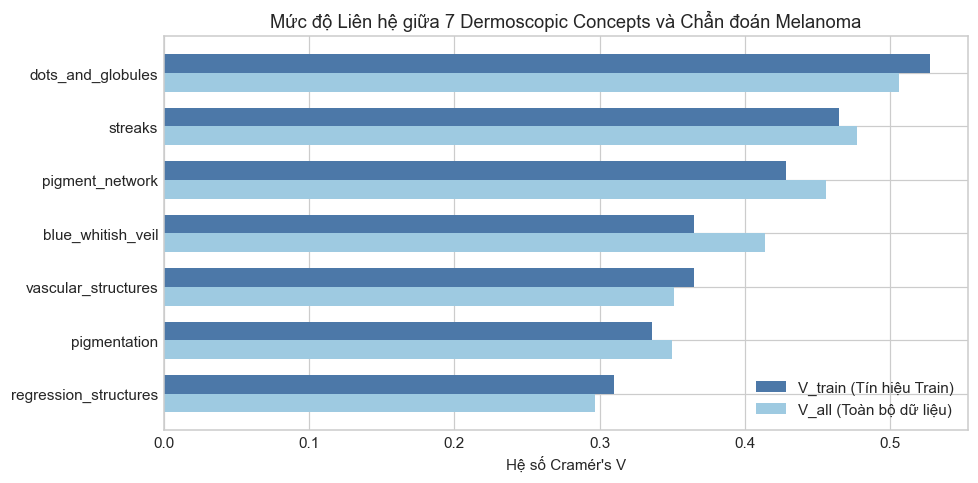

In [32]:
train_mask = (data["split"] == "train")

concept_diag_assoc = []
for concept in CONCEPT_COLUMNS:
    v_tr = cramers_v(data.loc[train_mask, concept], data.loc[train_mask, "diagnosis_binary"])
    v_all = cramers_v(data[concept], data["diagnosis_binary"])
    concept_diag_assoc.append({
        "concept": concept,
        "V_train (Modeling Signal)": v_tr,
        "V_all (Descriptive)": v_all,
        "delta (V_all - V_train)": v_all - v_tr,
    })

concept_diag_df = (
    pd.DataFrame(concept_diag_assoc)
    .sort_values(by="V_train (Modeling Signal)", ascending=False)
    .reset_index(drop=True)
)
concept_diag_df.index = concept_diag_df.index + 1
concept_diag_df.index.name = "Rank (Train)"

print("BẢNG XẾP HẠNG CRAMÉR'S V GIỮA CONCEPT VÀ CHẨN ĐOÁN MELANOMA:")
display(concept_diag_df)

fig, ax = plt.subplots(figsize=(9, 4.5))
y_pos = np.arange(len(concept_diag_df))
height = 0.35
ax.barh(y_pos - height/2, concept_diag_df["V_train (Modeling Signal)"], height, label="V_train (Tín hiệu Train)", color="#4C78A8")
ax.barh(y_pos + height/2, concept_diag_df["V_all (Descriptive)"], height, label="V_all (Toàn bộ dữ liệu)", color="#9ECAE1")
ax.set_yticks(y_pos)
ax.set_yticklabels(concept_diag_df["concept"])
ax.invert_yaxis()
ax.set_xlabel("Hệ số Cramér's V")
ax.set_title("Mức độ Liên hệ giữa 7 Dermoscopic Concepts và Chẩn đoán Melanoma")
ax.legend()
plt.tight_layout()
plt.show()

TOP TRẠNG THÁI CÓ TỶ LỆ MELANOMA CAO NHẤT TRÊN TẬP TRAIN (support_train >= 10):


,concept,state,support_train,melanoma_count_train,melanoma_rate_train,support_all,melanoma_count_all,melanoma_rate_all,status
26,vascular_structures,within regression,18,11,0.6111,46,28,0.6087,normal
13,regression_structures,combinations,40,23,0.5750,99,60,0.6061,normal
23,vascular_structures,dotted,18,10,0.5556,53,29,0.5472,normal
4,streaks,irregular,101,56,0.5545,251,152,0.6056,normal
19,blue_whitish_veil,present,74,40,0.5405,195,120,0.6154,normal
1,pigment_network,atypical,93,50,0.5376,230,138,0.6000,normal
16,dots_and_globules,irregular,173,82,0.4740,448,221,0.4933,normal
7,pigmentation,diffuse irregular,100,44,0.4400,265,127,0.4792,normal



CÁC TRẠNG THÁI CÓ TỶ LỆ MELANOMA CAO NHƯNG CỠ MẪU RẤT NHỎ TRONG TRAIN (support_train < 10):


,concept,state,support_train,melanoma_count_train,melanoma_rate_train,support_all,melanoma_count_all,melanoma_rate_all,status
25,vascular_structures,linear irregular,5,5,1.0000,18,17,0.9444,rare_in_train
24,vascular_structures,hairpin,4,1,0.2500,15,4,0.2667,rare_in_train
22,vascular_structures,comma,8,0,0.0000,23,0,0.0000,rare_in_train
27,vascular_structures,wreath,1,0,0.0000,2,0,0.0000,rare_in_train


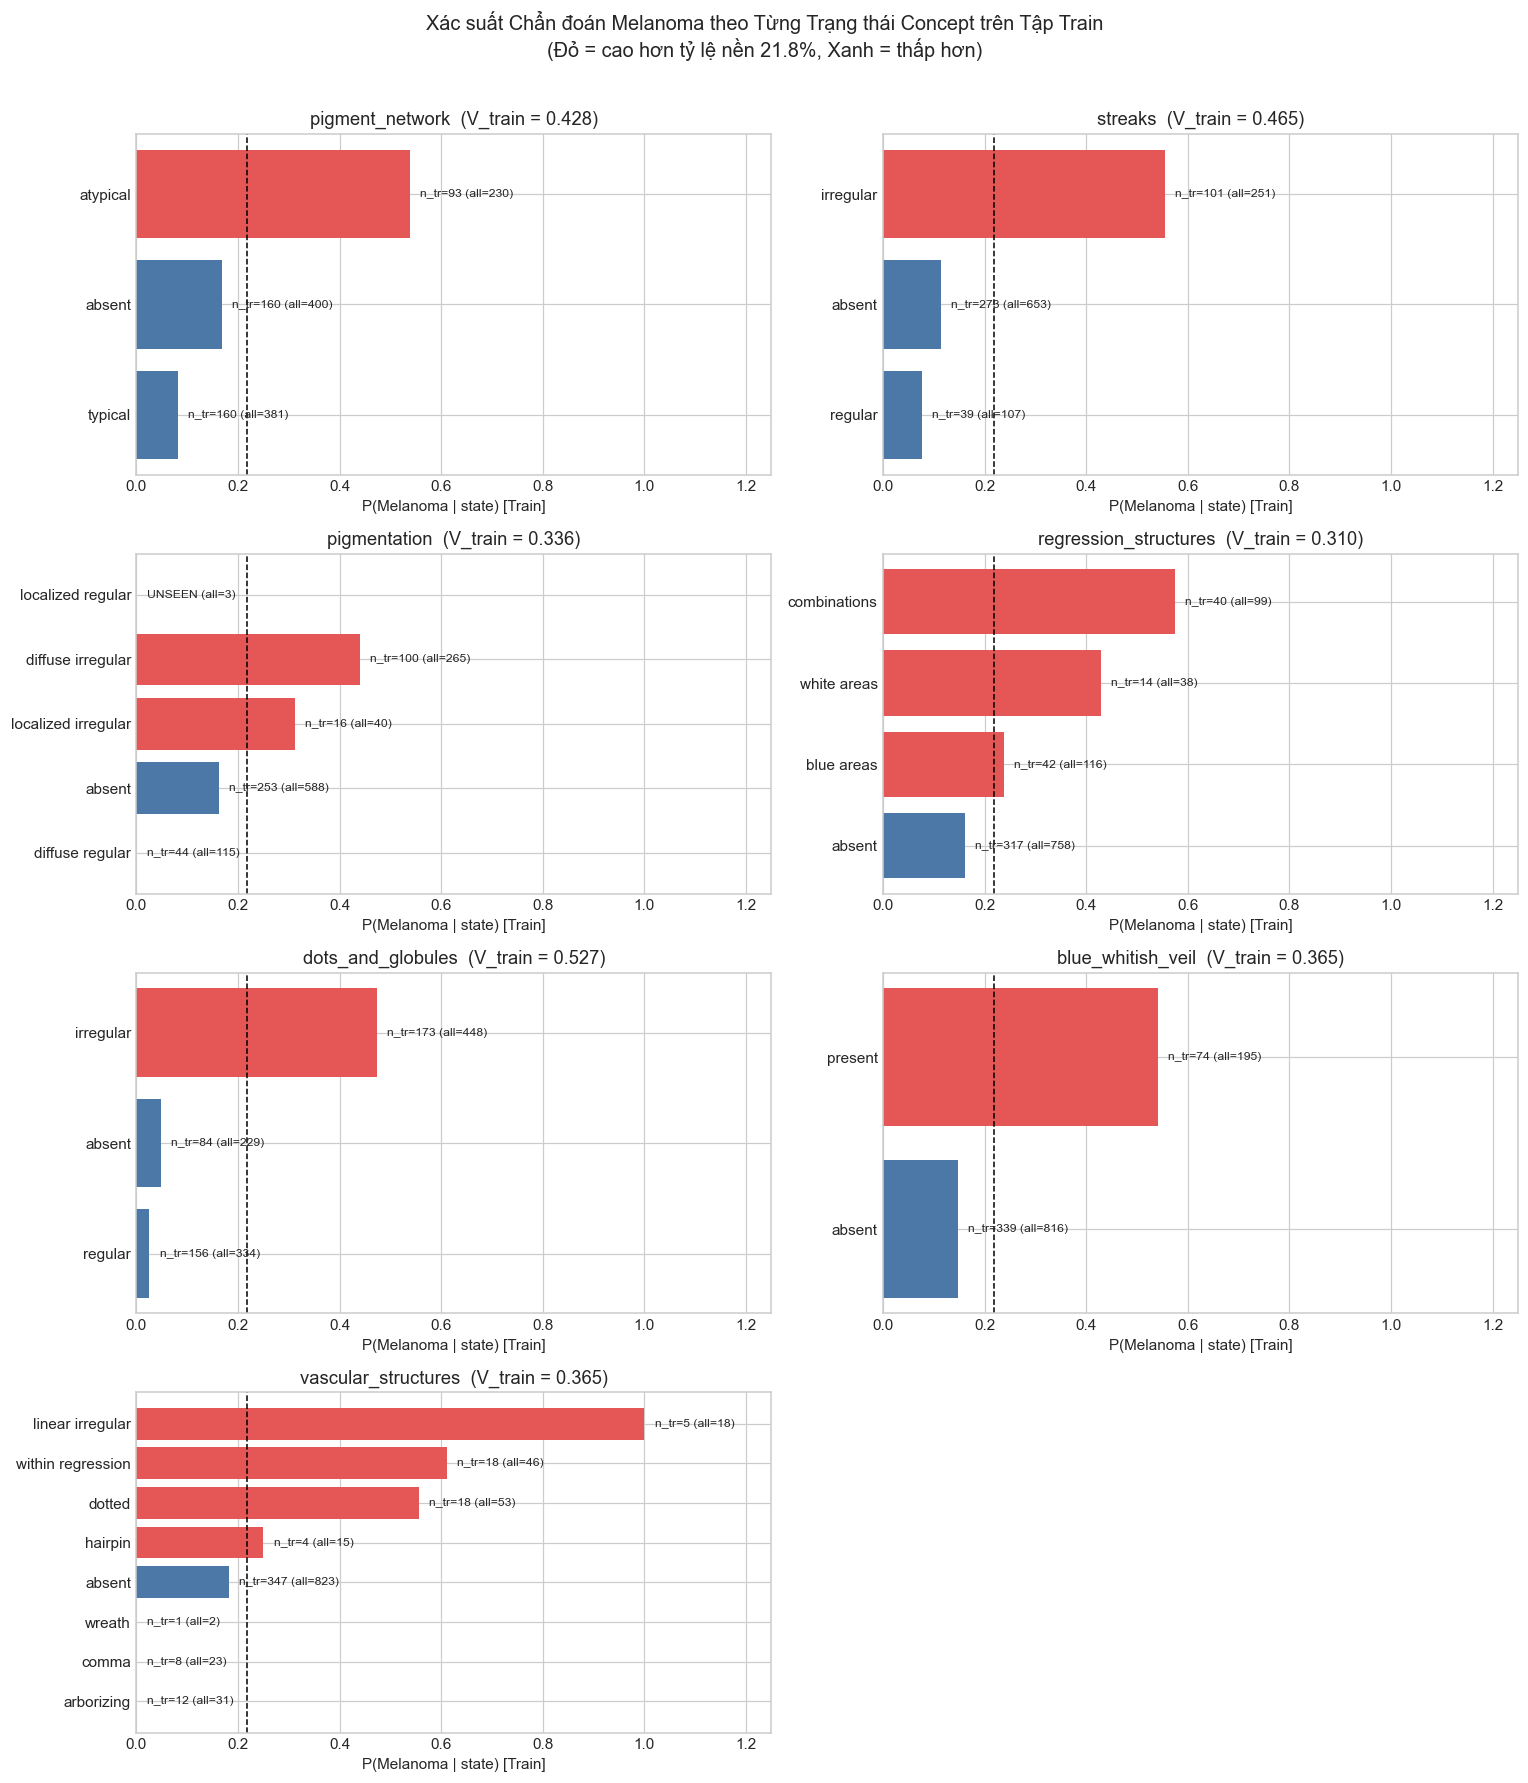

In [33]:
# Bảng đầy đủ P(Melanoma | state) trên cả Train và All
state_prob_df = concept_states_df[[
    "concept", "state", "support_train", "melanoma_count_train", "melanoma_rate_train",
    "support_all", "melanoma_count_all", "melanoma_rate_all", "status"
]].copy()

# Sắp xếp theo tỷ lệ Melanoma trên tập Train
print("TOP TRẠNG THÁI CÓ TỶ LỆ MELANOMA CAO NHẤT TRÊN TẬP TRAIN (support_train >= 10):")
reliable_train_states = state_prob_df[state_prob_df["support_train"] >= 10].sort_values("melanoma_rate_train", ascending=False)
display(reliable_train_states.head(8))

print("\nCÁC TRẠNG THÁI CÓ TỶ LỆ MELANOMA CAO NHƯNG CỠ MẪU RẤT NHỎ TRONG TRAIN (support_train < 10):")
low_support_states = state_prob_df[(state_prob_df["support_train"] < 10) & (state_prob_df["support_train"] > 0)].sort_values("melanoma_rate_train", ascending=False)
display(low_support_states)

# Trực quan hóa P(Melanoma | state) theo từng concept
train_global_rate = data.loc[train_mask, "diagnosis_binary"].mean()

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.ravel()

for axis, concept in zip(axes, CONCEPT_COLUMNS):
    v_tr = concept_diag_df.loc[concept_diag_df["concept"] == concept, "V_train (Modeling Signal)"].values[0]
    subset = state_prob_df[state_prob_df["concept"] == concept].sort_values("melanoma_rate_train", ascending=True)
    
    rates = subset["melanoma_rate_train"].fillna(0)
    colors = ["#E45756" if r > train_global_rate else "#4C78A8" for r in rates]
    
    bars = axis.barh(subset["state"], rates, color=colors)
    axis.axvline(train_global_rate, color="black", linestyle="--", linewidth=1, label="Tỷ lệ nền Train (21.8%)")
    
    for bar, (_, row) in zip(bars, subset.iterrows()):
        n_tr = int(row["support_train"])
        n_all = int(row["support_all"])
        rate_val = row["melanoma_rate_train"]
        txt = f"n_tr={n_tr} (all={n_all})" if pd.notna(rate_val) else f"UNSEEN (all={n_all})"
        axis.text(max(0.02, bar.get_width() + 0.02), bar.get_y() + bar.get_height() / 2, txt, va="center", fontsize=8)
        
    axis.set_title(f"{concept}  (V_train = {v_tr:.3f})")
    axis.set_xlabel("P(Melanoma | state) [Train]")
    axis.set_xlim(0, 1.25)

axes[-1].axis("off")
fig.suptitle("Xác suất Chẩn đoán Melanoma theo Từng Trạng thái Concept trên Tập Train\n(Đỏ = cao hơn tỷ lệ nền 21.8%, Xanh = thấp hơn)", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

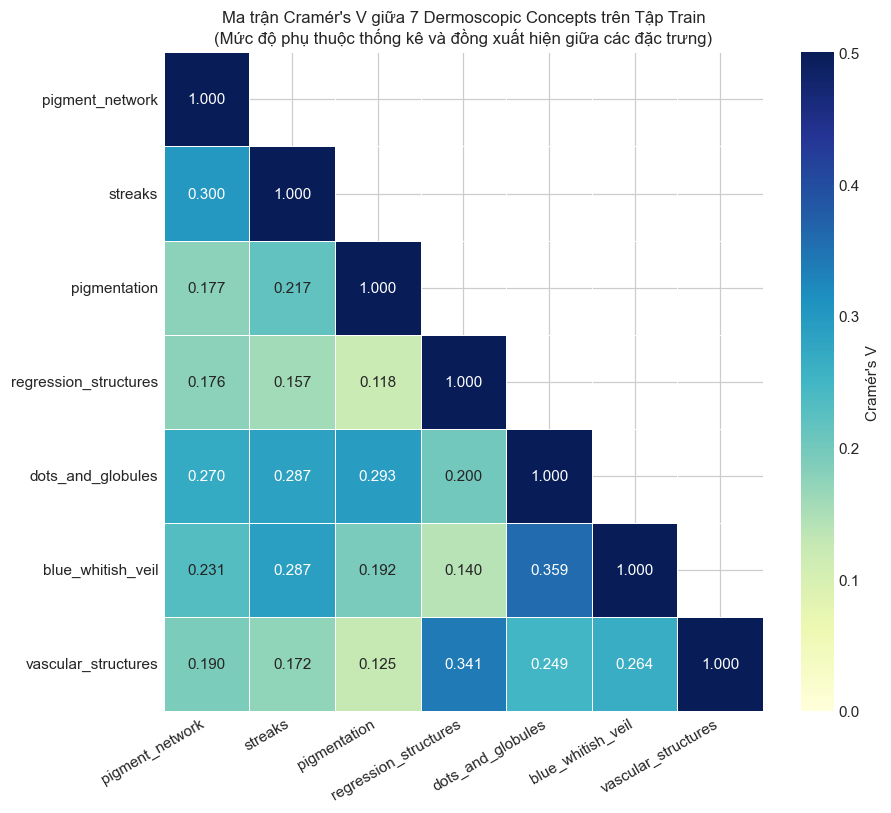

CÁC CẶP CONCEPT CÓ MỨC ĐỘ ĐỒNG XUẤT HIỆN CAO NHẤT:


,Concept 1,Concept 2,Cramér's V (Train),Cramér's V (All)
1,dots_and_globules,blue_whitish_veil,0.3590,0.3684
2,regression_structures,vascular_structures,0.3409,0.2917
3,pigment_network,streaks,0.3005,0.3301
4,pigmentation,dots_and_globules,0.2933,0.2952
5,streaks,blue_whitish_veil,0.2874,0.2959
6,streaks,dots_and_globules,0.2867,0.2719


In [34]:
# Ma trận Cramér's V 7x7 giữa tất cả các cặp concept trên tập TRAIN
cramer_matrix_train = pd.DataFrame(index=CONCEPT_COLUMNS, columns=CONCEPT_COLUMNS, dtype=float)
cramer_matrix_all = pd.DataFrame(index=CONCEPT_COLUMNS, columns=CONCEPT_COLUMNS, dtype=float)

train_data = data[data["split"] == "train"]

for c1 in CONCEPT_COLUMNS:
    for c2 in CONCEPT_COLUMNS:
        cramer_matrix_train.loc[c1, c2] = cramers_v(train_data[c1], train_data[c2])
        cramer_matrix_all.loc[c1, c2] = cramers_v(data[c1], data[c2])

# Trực quan hóa Heatmap Cramér's V 7x7
fig, ax = plt.subplots(figsize=(8.5, 7.5))
if sns is not None:
    mask = np.triu(np.ones_like(cramer_matrix_train, dtype=bool), k=1)
    sns.heatmap(
        cramer_matrix_train,
        mask=mask,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        vmin=0,
        vmax=0.5,
        cbar_kws={"label": "Cramér's V"},
        linewidths=0.5,
        ax=ax,
    )
    plt.xticks(rotation=30, ha="right")
else:
    im = ax.imshow(cramer_matrix_train.to_numpy(), cmap="YlGnBu", vmin=0, vmax=0.5)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Cramér's V")
    ax.set_xticks(np.arange(len(CONCEPT_COLUMNS)))
    ax.set_yticks(np.arange(len(CONCEPT_COLUMNS)))
    ax.set_xticklabels(CONCEPT_COLUMNS, rotation=30, ha="right")
    ax.set_yticklabels(CONCEPT_COLUMNS)
    for i in range(len(CONCEPT_COLUMNS)):
        for j in range(len(CONCEPT_COLUMNS)):
            val = cramer_matrix_train.iloc[i, j]
            color = "white" if val > 0.35 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", color=color, fontsize=9)

ax.set_title("Ma trận Cramér's V giữa 7 Dermoscopic Concepts trên Tập Train\n(Mức độ phụ thuộc thống kê và đồng xuất hiện giữa các đặc trưng)", fontsize=11)
plt.tight_layout()
plt.show()

# Liệt kê các cặp concept có phụ thuộc thống kê cao nhất
pair_records = []
for i in range(len(CONCEPT_COLUMNS)):
    for j in range(i + 1, len(CONCEPT_COLUMNS)):
        c1, c2 = CONCEPT_COLUMNS[i], CONCEPT_COLUMNS[j]
        pair_records.append({
            "Concept 1": c1,
            "Concept 2": c2,
            "Cramér's V (Train)": cramer_matrix_train.loc[c1, c2],
            "Cramér's V (All)": cramer_matrix_all.loc[c1, c2],
        })

top_pairs_df = pd.DataFrame(pair_records).sort_values("Cramér's V (Train)", ascending=False).reset_index(drop=True)
top_pairs_df.index = top_pairs_df.index + 1
print("CÁC CẶP CONCEPT CÓ MỨC ĐỘ ĐỒNG XUẤT HIỆN CAO NHẤT:")
display(top_pairs_df.head(6))

> **Diễn giải Học thuật về Tương tác Concept và Liên hệ Chẩn đoán:**
> 1. **Thứ tự liên hệ thực tế Concept ↔ Diagnosis:**
>    - Dữ liệu tính toán trên tập **Train** ghi nhận thứ tự liên hệ thống kê theo Cramér's V lần lượt là:
>      1. `dots_and_globules` ($V_{\text{train}} = 0.527$)
>      2. `streaks` ($V_{\text{train}} = 0.465$)
>      3. `pigment_network` ($V_{\text{train}} = 0.428$)
>      4. `blue_whitish_veil` ($V_{\text{train}} = 0.365$)
>      5. `vascular_structures` ($V_{\text{train}} = 0.365$)
>      6. `pigmentation` ($V_{\text{train}} = 0.336$)
>      7. `regression_structures` ($V_{\text{train}} = 0.310$)
>    - Thứ tự này được sử dụng như một kết quả mô tả về mức độ association giữa từng concept và diagnosis, đồng thời hỗ trợ phân tích và diễn giải kết quả mô hình về sau.
> 2. **Cảnh báo về các trạng thái cỡ mẫu nhỏ:**
>    - Trạng thái `vascular_structures = linear irregular` có tỷ lệ Melanoma trong train là $100\%$ ($5/5$ ca, $17/18$ ca trên toàn bộ dữ liệu). Tuy nhiên, vì cỡ mẫu rất nhỏ ($n_{\text{train}} = 5$), đây là tín hiệu cần thận trọng, không được suy diễn vội vã thành quy luật chẩn đoán tuyệt đối.
> 3. **Đánh giá mức độ phụ thuộc giữa các concepts:**
>    - Các trạng thái của các concept trong Derm7pt (đặc biệt là `vascular_structures` với 8 hình thái mạch máu: *absent, arborizing, comma, dotted, hairpin, linear irregular, within regression, wreath*) là các **biến định danh (nominal)**, không có thứ tự tự nhiên. Việc áp dụng `OrdinalEncoder` rồi tính Spearman correlation là không phù hợp về mặt thống kê.
>    - **Cramér's V phù hợp để mô tả mức độ association giữa các categorical concepts trong phân tích này.**
>    - **Diễn giải:** *Concept–concept association được khảo sát nhằm mô tả mức độ đồng xuất hiện và phụ thuộc thống kê giữa các đặc điểm dermoscopic. Các quan hệ này không mang ý nghĩa nhân quả (causal), mà cung cấp bối cảnh để phân tích các interaction giữa concepts mà ECBM có thể mô hình hóa.*
>    - Không tuyên bố rằng mô hình CBM chuẩn giả định các concepts độc lập, và không suy diễn rằng pairwise Cramér's V chính là các tương tác mà ECBM chắc chắn sẽ học.

,total,melanoma,melanoma_rate,melanoma_rate_pct
seven_point_score,,,,
0,311,2,0.0064,0.6431
1,166,7,0.0422,4.2169
2,165,9,0.0545,5.4545
3,91,39,0.4286,42.8571
4,96,51,0.5312,53.1250
5,81,56,0.6914,69.1358
6,50,41,0.8200,82.0000
7,28,26,0.9286,92.8571
8,14,13,0.9286,92.8571


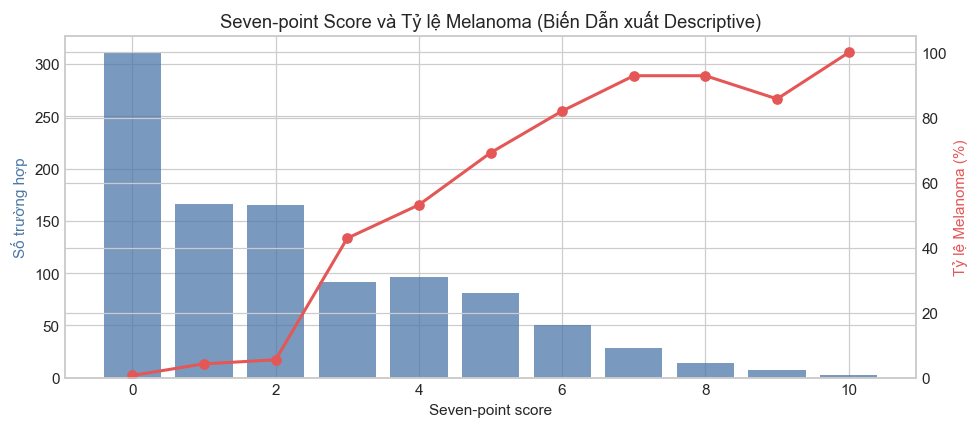

**Quyết định thiết kế Concept Bottleneck:** `seven_point_score` là biến dẫn xuất (derived variable) được tổng hợp bằng phép cộng điểm quy ước từ các tiêu chí dermoscopic lâm sàng. Nghiên cứu này **giữ seven_point_score ngoài concept bottleneck**, không bổ sung nó thành concept thứ 8 để tránh hiện tượng trùng lặp thông tin (redundancy) và bảo đảm tính toàn vẹn của không gian can thiệp concept (concept intervention) khi mô hình hóa CBM và ECBM.

In [35]:
score_summary = (
    data.groupby("seven_point_score")["diagnosis_binary"]
    .agg(total="size", melanoma="sum", melanoma_rate="mean")
)
score_summary["melanoma_rate_pct"] = score_summary["melanoma_rate"] * 100
display(score_summary)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.bar(score_summary.index, score_summary["total"], color="#4C78A8", alpha=0.75, label="Số lượng ca")
ax1.set_xlabel("Seven-point score")
ax1.set_ylabel("Số trường hợp", color="#4C78A8")
ax2 = ax1.twinx()
ax2.plot(score_summary.index, score_summary["melanoma_rate_pct"], color="#E45756", marker="o", linewidth=2, label="Tỷ lệ Melanoma (%)")
ax2.set_ylabel("Tỷ lệ Melanoma (%)", color="#E45756")
ax2.set_ylim(0, 105)
ax1.set_title("Seven-point Score và Tỷ lệ Melanoma (Biến Dẫn xuất Descriptive)")
plt.tight_layout()
plt.show()

display(Markdown(
    "**Quyết định thiết kế Concept Bottleneck:** "
    "`seven_point_score` là biến dẫn xuất (derived variable) được tổng hợp bằng phép cộng điểm quy ước từ các tiêu chí dermoscopic lâm sàng. "
    "Nghiên cứu này **giữ seven_point_score ngoài concept bottleneck**, không bổ sung nó thành concept thứ 8 để tránh hiện tượng trùng lặp thông tin (redundancy) "
    "và bảo đảm tính toàn vẹn của không gian can thiệp concept (concept intervention) khi mô hình hóa CBM và ECBM."
))

## 6. Hiện tượng Concept Profile Inconsistency và Bảng Phân tích Consistency × Diagnosis × Split

Một **concept profile** được định nghĩa chính xác bằng bộ 7 giá trị concept categorical:
$$C = (C_1, C_2, \dots, C_7)$$

Một profile được gọi là **mâu thuẫn nhãn (inconsistent)** nếu cùng một tổ hợp chính xác của 7 concepts này xuất hiện đồng thời với cả chẩn đoán **Melanoma ($y = 1$)** và **Non-Melanoma ($y = 0$)** (theo Nápoles et al., 2026).

Phần này phân tích:
1. Số lượng và tỷ lệ concept profiles mâu thuẫn.
2. Giới hạn trên thực nghiệm của bộ phân loại tất định chỉ sử dụng exact 7-concept profiles trên Derm7pt (*Empirical upper bound for deterministic hard concept-only classification on the observed Derm7pt dataset*).
3. **Bảng phân tích bắt buộc:** Phân rã theo `Split × Diagnosis × Consistent × Inconsistent`.

In [36]:
profile_stats = (
    data.groupby(CONCEPT_COLUMNS, dropna=False)["diagnosis_binary"]
    .agg(n="size", melanoma="sum", n_labels="nunique")
    .reset_index()
)
profile_stats["non_melanoma"] = profile_stats["n"] - profile_stats["melanoma"]
profile_stats["is_inconsistent"] = profile_stats["n_labels"] > 1

# Đưa cờ is_inconsistent_profile vào bảng dữ liệu chính
inconsistent_profiles = profile_stats[profile_stats["is_inconsistent"]].copy()
inconsistent_profile_set = set(
    tuple(x) for x in inconsistent_profiles[CONCEPT_COLUMNS].to_numpy()
)

data["concept_profile"] = [
    " | ".join(map(str, row)) for row in data[CONCEPT_COLUMNS].to_numpy()
]
data["is_inconsistent_profile"] = [
    tuple(row) in inconsistent_profile_set
    for row in data[CONCEPT_COLUMNS].to_numpy()
]

# Thống kê tổng quan
n_unique_profiles = len(profile_stats)
n_incon_profiles = len(inconsistent_profiles)
pct_incon_profiles = (n_incon_profiles / n_unique_profiles) * 100

n_cases_incon = int(data["is_inconsistent_profile"].sum())
pct_cases_incon = (n_cases_incon / len(data)) * 100

melanoma_cases = data[data["diagnosis_binary"] == 1]
n_mel_incon = int(melanoma_cases["is_inconsistent_profile"].sum())
pct_mel_incon = (n_mel_incon / len(melanoma_cases)) * 100

# Giới hạn trên thực nghiệm của bộ phân loại tất định chỉ sử dụng exact 7-concept profiles trên Derm7pt
# Empirical upper bound for deterministic hard concept-only classification on the observed Derm7pt dataset:
# Với mỗi profile, dự đoán tất định gán nhãn đa số: max(melanoma, non_melanoma)
majority_correct = profile_stats.apply(lambda r: max(r["melanoma"], r["non_melanoma"]), axis=1).sum()
empirical_upper_bound = (majority_correct / len(data)) * 100

incon_summary_table = pd.DataFrame([
    ("Tổng số unique concept profiles", f"{n_unique_profiles:,}"),
    ("Số profiles bị mâu thuẫn (inconsistent)", f"{n_incon_profiles:,} ({pct_incon_profiles:.2f}%)"),
    ("Tổng số ca thuộc profiles mâu thuẫn", f"{n_cases_incon:,} / {len(data):,} ({pct_cases_incon:.2f}%)"),
    ("Số ca Melanoma thuộc profiles mâu thuẫn", f"{n_mel_incon:,} / {len(melanoma_cases):,} ({pct_mel_incon:.2f}%)"),
    ("Empirical Upper Bound (Deterministic Hard Concept Classifier)", f"{empirical_upper_bound:.2f}% ({majority_correct}/{len(data)})"),
], columns=["Chỉ số Inconsistency", "Giá trị thực tế"])
display(incon_summary_table)

# Hiển thị 8 profiles mâu thuẫn lớn nhất
print("\nDANH SÁCH CÁC CONCEPT PROFILES MÂU THUẪN CÓ QUY MÔ LỚN NHẤT:")
largest_conflicts = (
    inconsistent_profiles.sort_values(["n", "melanoma"], ascending=False).head(8)
)
display(largest_conflicts[CONCEPT_COLUMNS + ["n", "melanoma", "non_melanoma"]])

,Chỉ số Inconsistency,Giá trị thực tế
0,Tổng số unique concept profiles,305
1,Số profiles bị mâu thuẫn (inconsistent),50 (16.39%)
2,Tổng số ca thuộc profiles mâu thuẫn,"306 / 1,011 (30.27%)"
3,Số ca Melanoma thuộc profiles mâu thuẫn,136 / 252 (53.97%)
4,Empirical Upper Bound (Deterministic Hard Conc...,92.09% (931/1011)



DANH SÁCH CÁC CONCEPT PROFILES MÂU THUẪN CÓ QUY MÔ LỚN NHẤT:


,pigment_network,streaks,pigmentation,regression_structures,dots_and_globules,blue_whitish_veil,vascular_structures,n,melanoma,non_melanoma
34,absent,absent,diffuse irregular,absent,absent,absent,absent,19,1,18
179,atypical,irregular,diffuse irregular,absent,irregular,absent,absent,16,15,1
87,absent,irregular,diffuse irregular,absent,irregular,present,absent,14,8,6
222,typical,absent,absent,blue areas,irregular,absent,absent,13,2,11
242,typical,absent,diffuse irregular,absent,irregular,absent,absent,13,1,12
125,atypical,absent,absent,absent,irregular,absent,absent,11,5,6
6,absent,absent,absent,absent,irregular,absent,absent,11,2,9
180,atypical,irregular,diffuse irregular,absent,irregular,present,absent,10,9,1


BẢNG PHÂN TÍCH CONSISTENCY × DIAGNOSIS × SPLIT:


,Split,Diagnosis,Consistent,Inconsistent,Total,% Inconsistent
0,Train,Melanoma,42,48,90,53.33%
1,Train,Non-Melanoma,256,67,323,20.74%
2,Valid,Melanoma,25,36,61,59.02%
3,Valid,Non-Melanoma,110,32,142,22.54%
4,Test,Melanoma,49,52,101,51.49%
5,Test,Non-Melanoma,223,71,294,24.15%


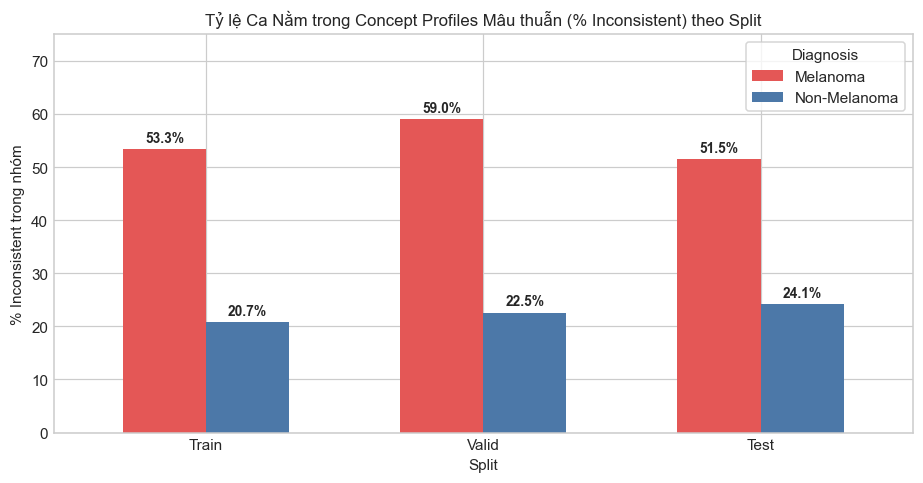

In [37]:
# BẢNG BẮT BUỘC: Split x Diagnosis x Consistent x Inconsistent x % Inconsistent
consistency_split_rows = []

for split in ["train", "valid", "test"]:
    for diag_label, diag_name in [(1, "Melanoma"), (0, "Non-Melanoma")]:
        sub = data[(data["split"] == split) & (data["diagnosis_binary"] == diag_label)]
        tot = len(sub)
        incon = int(sub["is_inconsistent_profile"].sum())
        con = tot - incon
        pct_incon = (incon / tot * 100) if tot > 0 else 0.0
        consistency_split_rows.append({
            "Split": split.capitalize(),
            "Diagnosis": diag_name,
            "Consistent": con,
            "Inconsistent": incon,
            "Total": tot,
            "% Inconsistent": pct_incon,
        })

consistency_split_df = pd.DataFrame(consistency_split_rows)
consistency_split_display = consistency_split_df.copy()
consistency_split_display["% Inconsistent"] = consistency_split_display["% Inconsistent"].map(lambda v: f"{v:.2f}%")

print("BẢNG PHÂN TÍCH CONSISTENCY × DIAGNOSIS × SPLIT:")
display(consistency_split_display)

# Trực quan hóa tỷ lệ Inconsistent giữa Melanoma và Non-Melanoma theo từng Split
fig, ax = plt.subplots(figsize=(8.5, 4.5))
pivot_plot = consistency_split_df.pivot(index="Split", columns="Diagnosis", values="% Inconsistent").reindex(["Train", "Valid", "Test"])
bars = pivot_plot.plot(kind="bar", color=["#E45756", "#4C78A8"], ax=ax, width=0.6)
ax.set_title("Tỷ lệ Ca Nằm trong Concept Profiles Mâu thuẫn (% Inconsistent) theo Split", fontsize=11)
ax.set_ylabel("% Inconsistent trong nhóm")
ax.set_xlabel("Split")
ax.tick_params(axis="x", rotation=0)
ax.set_ylim(0, 75)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9, weight="bold")

plt.legend(title="Diagnosis", frameon=True)
plt.tight_layout()
plt.show()

> [!IMPORTANT]
> **Hàm ý Nghiên cứu từ Phân tích Concept Inconsistency:**
> 1. **Hiện tượng mâu thuẫn đặc trưng:**
>    - Có tới **$30.27\%$ số ca trong bộ dữ liệu** ($306/1011$ ca) mang tổ hợp 7 concept bị trùng lặp giữa hai nhóm chẩn đoán.
>    - Đáng chú ý, **hơn $50\%$ số ca Melanoma** nằm trong các profiles mâu thuẫn này ($53.33\%$ ở Train, $59.02\%$ ở Valid, và $51.49\%$ ở Test).
> 2. **Ý nghĩa khoa học:**
>    - Tuyệt đối **KHÔNG** xóa các mẫu này và không tự tiện quy chụp chúng là lỗi gán nhãn (label errors).
>    - Hiện tượng này phản ánh một giới hạn thực tế về tính đầy đủ chẩn đoán (*diagnostic sufficiency*) của 7 tiêu chí dermoscopy quan sát được: hai tổn thương có cùng biểu hiện hiển vi bề mặt vẫn có thể khác nhau về bản chất giải phẫu bệnh ác tính.
> 3. **Phạm vi áp dụng của con số 92.09%:**
>    - Mức $\approx 92.09\%$ là **giới hạn trên thực nghiệm của bộ phân loại tất định chỉ sử dụng exact 7-concept profiles trên Derm7pt** (*Empirical upper bound for deterministic hard concept-only classification on the observed Derm7pt dataset*). Giới hạn này chỉ áp dụng cho bộ phân loại tất định hoàn toàn dựa vào exact hard concept profiles trong biểu diễn hiện tại.
>    - **Không khẳng định** rằng mọi mô hình CBM, Soft CBM hay ECBM đều bị giới hạn ở 92.09%, vì các kiến trúc có thể khai thác biểu diễn xác suất mềm, concept embeddings hoặc luồng thông tin bổ trợ từ ảnh.
> 4. **Mục đích chuẩn bị cho thực nghiệm downstream:**
>    - Bảng phân tích này thiết lập cơ sở vững chắc cho thực nghiệm stratified evaluation sau này:
>      $$\text{Performance}_{\text{CBM}}^{\text{consistent}} \quad \text{vs} \quad \text{Performance}_{\text{CBM}}^{\text{inconsistent}}$$
>      $$\text{Performance}_{\text{ECBM}}^{\text{consistent}} \quad \text{vs} \quad \text{Performance}_{\text{ECBM}}^{\text{inconsistent}}$$
>    - **Giả thuyết nghiên cứu:** Đánh giá liệu cơ chế joint energy của ECBM có giúp cải thiện hiệu năng trên các mẫu thuộc concept-profile inconsistent region so với CBM hay không. Tuyệt đối không trình bày ECBM > CBM như một kết luận đã biết trước, và không sử dụng consistency label trong quá trình huấn luyện.

## 7. Phân tích Đặc tính Ảnh Dermoscopy và Hiện vật Thị giác (Image Quality & Anomaly Analysis)

Phần này khảo sát các thuộc tính kỹ thuật của ảnh:
- Kích thước không gian (width, height, aspect ratio).
- Số lượng kênh màu và chế độ ảnh.
- Thuộc tính xoay EXIF.
- Các hiện vật thị giác (visual artifacts): lông/tóc, thước đo bọt khí viền đen...

THỐNG KÊ KÍCH THƯỚC ẢNH DERMOSCOPY:


,width,height,aspect_ratio
count,"1,011.0000","1,011.0000","1,011.0000"
mean,767.4936,511.8675,1.4994
std,9.5254,1.7103,0.0170
min,512.0000,474.0000,1.0000
25%,768.0000,512.0000,1.5000
50%,768.0000,512.0000,1.5000
75%,768.0000,512.0000,1.5000
max,768.0000,532.0000,1.5299



CÁC CỠ ẢNH PHỔ BIẾN NHẤT:


,width,height,count
0,768,512,941
1,768,511,57
2,767,508,3
3,768,509,2
4,512,512,1



Kiểm tra chế độ màu (Color Modes): {'RGB': 1011} (100% RGB)
Kiểm tra EXIF orientation: {1: 1011} (100% chuẩn)


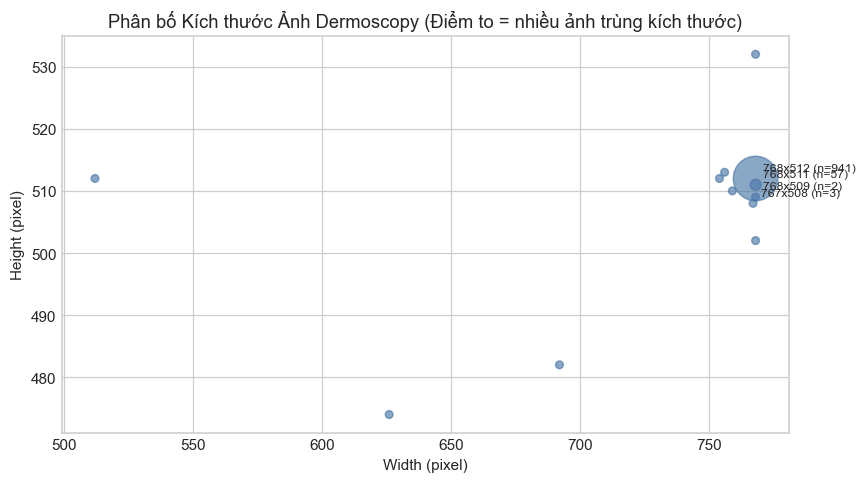

In [38]:
image_records = []
for row in data.itertuples(index=False):
    path = Path(row.derm_path_resolved)
    try:
        with Image.open(path) as image:
            width, height = image.size
            image_records.append({
                "case_num": row.case_num,
                "split": row.split,
                "diagnosis_binary": row.diagnosis_binary,
                "path": path,
                "width": width,
                "height": height,
                "aspect_ratio": width / height,
                "mode": image.mode,
                "exif_orientation": image.getexif().get(274, 1),
                "decode_ok": True,
            })
    except Exception:
        image_records.append({
            "case_num": row.case_num,
            "split": row.split,
            "diagnosis_binary": row.diagnosis_binary,
            "path": path,
            "decode_ok": False,
        })

image_info = pd.DataFrame(image_records)

print("THỐNG KÊ KÍCH THƯỚC ẢNH DERMOSCOPY:")
display(image_info[["width", "height", "aspect_ratio"]].describe())

dimension_counts = (
    image_info.groupby(["width", "height"]).size().rename("count")
    .sort_values(ascending=False).reset_index()
)
print("\nCÁC CỠ ẢNH PHỔ BIẾN NHẤT:")
display(dimension_counts.head(5))

print(f"\nKiểm tra chế độ màu (Color Modes): {image_info['mode'].value_counts().to_dict()} (100% RGB)")
print(f"Kiểm tra EXIF orientation: {image_info['exif_orientation'].value_counts().to_dict()} (100% chuẩn)")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(
    dimension_counts["width"],
    dimension_counts["height"],
    s=np.maximum(25, dimension_counts["count"] * 0.9),
    alpha=0.65,
    color="#4C78A8",
)
ax.set_title("Phân bố Kích thước Ảnh Dermoscopy (Điểm to = nhiều ảnh trùng kích thước)")
ax.set_xlabel("Width (pixel)")
ax.set_ylabel("Height (pixel)")
for row in dimension_counts.head(4).itertuples(index=False):
    ax.annotate(f"{row.width}x{row.height} (n={row.count})", (row.width, row.height), xytext=(5, 5), textcoords="offset points", fontsize=8)
plt.tight_layout()
plt.show()

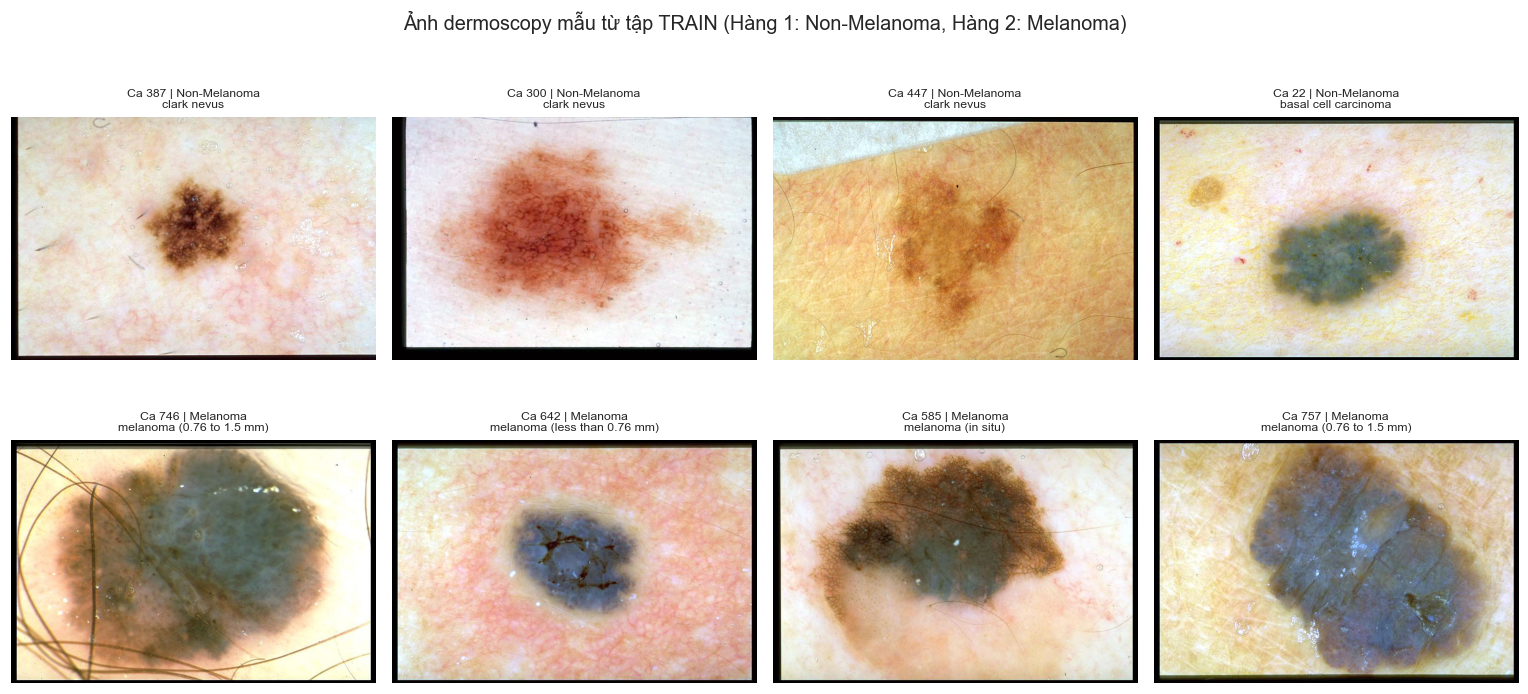

In [39]:
train_samples = pd.concat([
    data[(data["split"] == "train") & (data["diagnosis_binary"] == label)]
    .sample(n=4, random_state=RANDOM_SEED + label)
    for label in [0, 1]
], ignore_index=True)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for axis, row in zip(axes.ravel(), train_samples.itertuples(index=False)):
    with Image.open(Path(row.derm_path_resolved)) as image:
        axis.imshow(image.convert("RGB"))
    axis.set_title(
        f"Ca {row.case_num} | {row.diagnosis_binary_name}\n{row.diagnosis}",
        fontsize=8,
    )
    axis.axis("off")

fig.suptitle("Ảnh dermoscopy mẫu từ tập TRAIN (Hàng 1: Non-Melanoma, Hàng 2: Melanoma)", fontsize=13)
plt.tight_layout()
plt.show()

> [!NOTE]
> **Đặc trưng Kỹ thuật Ảnh & Chính sách Tiền xử lý:**
> 1. **Quy cách ảnh:** $100\%$ ($1.011/1.011$) ảnh đọc bình thường dưới định dạng RGB, định hướng EXIF chuẩn. Kích thước chủ đạo là $768 \times 512$ pixel ($941$ ảnh, chiếm $93.1\%$).
> 2. **Hiện vật thị giác (Artifacts):** Ảnh dermoscopy thực tế thường chứa các yếu tố gây nhiễu như sợi lông/tóc, bọt gel, thước đo centimet, viền tối (vignetting) và biến thiên ánh sáng.
> 3. **Chính sách thực nghiệm:**
>    - **Tuyệt đối KHÔNG** thực hiện loại bỏ mẫu dị biệt (outlier removal) tự động dựa trên độ sáng, độ mờ hay kích thước tổn thương.
>    - **Không** thêm các bước xử lý phức tạp như cạo lông tự động (hair removal) hay phân vùng tổn thương (lesion segmentation) vào EDA.
>    - Giữ nguyên pipeline tiền xử lý (resize/crop, chuẩn hóa ImageNet) hoàn toàn đồng nhất giữa tất cả các mô hình M1 (Black-box), M3 (Joint CBM) và M5 (ECBM) để bảo đảm tính công bằng tuyệt đối trong so sánh.

## 8. Biểu diễn Dữ liệu và Xuất Manifest Phục vụ Mô hình Hóa

Manifest là tệp trung gian chứa toàn bộ metadata, đường dẫn tương đối đã chuẩn hóa, nhãn chẩn đoán nhị phân, 7 concepts và cờ đánh dấu profile mâu thuẫn.
Phần này kiểm tra cấu trúc manifest và ví dụ tensor representation cho DataLoader.

In [40]:
# Evaluation-only metadata. MUST NOT be used as model input or training target.
# Cột is_inconsistent_profile là siêu dữ liệu CHỈ DÙNG CHO ĐÁNH GIÁ (evaluation-only).
# TUYỆT ĐỐI KHÔNG được sử dụng:
# - làm đầu vào mô hình (model input);
# - làm nhãn huấn luyện (training target);
# - làm đặc trưng phụ (auxiliary feature);
# - để thay đổi hàm mất mát (loss weighting);
# - để lựa chọn mẫu trong huấn luyện (sample selection).
# Biến này chỉ được dùng để phân tầng (stratify) đánh giá hiệu năng: consistent vs inconsistent.

manifest_columns = [
    "source_index",
    "case_num",
    "split",
    "derm",
    "derm_path_resolved",
    "diagnosis",
    "diagnosis_binary",
    *CONCEPT_COLUMNS,
    "concept_profile",
    "is_inconsistent_profile",
]

manifest_data = data[manifest_columns].copy()

# Chuẩn hóa đường dẫn tương đối so với PROJECT_ROOT để bảo đảm tính di động (portability)
manifest_data["derm_path_resolved"] = manifest_data["derm_path_resolved"].map(
    lambda path: str(Path(path).relative_to(PROJECT_ROOT))
)

display(manifest_data.head(3))

# Xác nhận và ghi manifest ra thư mục data/
OUT_DIR = PROJECT_ROOT / "data"
OUT_DIR.mkdir(parents=True, exist_ok=True)
manifest_output_path = OUT_DIR / "manifest.csv"

manifest_data.to_csv(manifest_output_path, index=False)
print(f"Đã cập nhật manifest thành công tại: {manifest_output_path}")
print(f"Kích thước manifest: {manifest_data.shape}")

# Minh họa mẫu tensor biểu diễn cho DataLoader
sample_row = data.iloc[0]
sample_representation = {
    "case_num": int(sample_row["case_num"]),
    "split": sample_row["split"],
    "image_path": manifest_data.iloc[0]["derm_path_resolved"],
    "target_y": int(sample_row["diagnosis_binary"]),
    "concepts_c": {
        c: official_label_mapping[c][sample_row[c]] for c in CONCEPT_COLUMNS
    },
    "is_inconsistent (EVALUATION ONLY)": bool(sample_row["is_inconsistent_profile"]),
}

print("\nVí dụ biểu diễn một mẫu dữ liệu đưa vào PyTorch Dataset / DataLoader:")
print(json.dumps(sample_representation, indent=2, ensure_ascii=False))

,source_index,case_num,split,derm,derm_path_resolved,diagnosis,diagnosis_binary,pigment_network,streaks,pigmentation,regression_structures,dots_and_globules,blue_whitish_veil,vascular_structures,concept_profile,is_inconsistent_profile
0,0,1,train,NEL/Nel026.jpg,Derm7pt/release_v0/images/NEL/Nel026.jpg,basal cell carcinoma,0,absent,absent,absent,absent,absent,absent,arborizing,absent | absent | absent | absent | absent | a...,False
1,1,2,valid,NEL/Nel028.jpg,Derm7pt/release_v0/images/NEL/Nel028.jpg,basal cell carcinoma,0,absent,absent,absent,absent,irregular,absent,absent,absent | absent | absent | absent | irregular ...,True
2,2,3,train,NEL/Nel033.jpg,Derm7pt/release_v0/images/NEL/Nel033.jpg,basal cell carcinoma,0,absent,absent,absent,absent,irregular,absent,arborizing,absent | absent | absent | absent | irregular ...,False


Đã cập nhật manifest thành công tại: /Users/nhathuy/Desktop/HK1_26-27/KLTN/PROJECT/data/manifest.csv
Kích thước manifest: (1011, 16)

Ví dụ biểu diễn một mẫu dữ liệu đưa vào PyTorch Dataset / DataLoader:
{
  "case_num": 1,
  "split": "train",
  "image_path": "Derm7pt/release_v0/images/NEL/Nel026.jpg",
  "target_y": 0,
  "concepts_c": {
    "pigment_network": 0,
    "streaks": 0,
    "pigmentation": 0,
    "regression_structures": 0,
    "dots_and_globules": 0,
    "blue_whitish_veil": 0,
    "vascular_structures": 1
  },
  "is_inconsistent (EVALUATION ONLY)": false
}


In [41]:
decision_table = pd.DataFrame([
    ("Input X", "Ảnh dermoscopy RGB", "Resize về 224x224 chuẩn hóa theo ImageNet; không dùng ảnh lâm sàng clinic hay metadata phụ."),
    ("Target Y", "Melanoma vs Non-Melanoma", "Nhãn nhị phân: 1 nếu diagnosis bắt đầu bằng 'melanoma', 0 cho các tổn thương còn lại."),
    ("Concept C", "7 categorical concepts", "Bảo toàn cấu trúc C = (C1, ..., C7) với 28 states; không diễn giải thành 28 binary độc lập."),
    ("Concept Heads (M3)", "7 Categorical Softmax Heads (Soft CBM)", "Kích thước [3, 3, 5, 4, 3, 2, 8] tương ứng từng concept; áp dụng cho M2 và M3. Đối với M5 (ECBM), parameterization concept sẽ được xác định ở giai đoạn adaptation riêng."),
    ("Official Split", "413 Train / 203 Valid / 395 Test", "Giữ nguyên official split theo công bố của Kawahara et al. (2019); không xáo trộn."),
    ("Imbalance Handling", "Class weighting là candidate strategy", "Train có tỷ lệ Non-Mel:Mel = 3.59:1; chỉ tính từ TRAIN, hiệu quả cuối cùng phải kiểm chứng bằng validation."),
    ("Unseen States", "Giữ nguyên localized regular", "Có 3 mẫu trong Test, 0 mẫu trong Train; không xóa, không merge; phản ánh trung thực hiệu năng test."),
    ("Concept Inconsistency", "Giữ nguyên 30.3% ca mâu thuẫn", "Evaluation-only metadata; dùng phân tầng đánh giá (stratified evaluation) so sánh CBM vs ECBM."),
    ("Concept Metrics", "Accuracy, Macro-F1 (all-defined & train-observed)", "Macro-F1 tính riêng trên state space của từng concept C_i (F1_macro(C_i)), sau đó lấy mean qua 7 concepts. Báo cáo song song: (1) All-defined: 28 tổng states trên 7 concepts; (2) Train-observed: 27 tổng states (loại `pigmentation=localized regular`). Con số 28/27 là TỔNG states — không phải 28-class/27-class classification."),
    ("Test Discipline", "Test Discipline", "Tập test được phép sử dụng trong EDA cho các kiểm toán mô tả đã xác định trước. Không sử dụng bất kỳ thống kê nào từ test để lựa chọn kiến trúc, loss, class weight, augmentation, hyperparameter, threshold, checkpoint, early stopping hoặc bất kỳ quyết định tối ưu hóa mô hình nào. Hiệu năng dự đoán cuối cùng trên test chỉ được báo cáo sau khi modeling/evaluation protocol đã được cố định."),
], columns=["Thành phần", "Quyết định Thiết kế", "Lý do / Hướng dẫn Thực nghiệm"])

print("BẢNG TỔNG HỢP CÁC QUYẾT ĐỊNH THIẾT KẾ MÔ HÌNH HÓA (MODELING DESIGN DECISIONS):")
display(decision_table)

BẢNG TỔNG HỢP CÁC QUYẾT ĐỊNH THIẾT KẾ MÔ HÌNH HÓA (MODELING DESIGN DECISIONS):


,Thành phần,Quyết định Thiết kế,Lý do / Hướng dẫn Thực nghiệm
0,Input X,Ảnh dermoscopy RGB,Resize về 224x224 chuẩn hóa theo ImageNet; khô...
1,Target Y,Melanoma vs Non-Melanoma,Nhãn nhị phân: 1 nếu diagnosis bắt đầu bằng 'm...
2,Concept C,7 categorical concepts,"Bảo toàn cấu trúc C = (C1, ..., C7) với 28 sta..."
3,Concept Heads (M3),7 Categorical Softmax Heads (Soft CBM),"Kích thước [3, 3, 5, 4, 3, 2, 8] tương ứng từn..."
4,Official Split,413 Train / 203 Valid / 395 Test,Giữ nguyên official split theo công bố của Kaw...
5,Imbalance Handling,Class weighting là candidate strategy,Train có tỷ lệ Non-Mel:Mel = 3.59:1; chỉ tính ...
6,Unseen States,Giữ nguyên localized regular,"Có 3 mẫu trong Test, 0 mẫu trong Train; không ..."
7,Concept Inconsistency,Giữ nguyên 30.3% ca mâu thuẫn,Evaluation-only metadata; dùng phân tầng đánh ...
8,Concept Metrics,"Accuracy, Macro-F1 (all-defined & train-observed)",Macro-F1 tính riêng trên state space của từng ...
9,Test Discipline,Test Discipline,Tập test được phép sử dụng trong EDA cho các k...


## 9. EDA Summary for Modeling (Tóm tắt EDA cho Mô hình Hóa)

Phần tóm tắt này đúc kết 10 phát hiện cốt lõi từ dữ liệu thực tế của `Derm7pt` và xác lập các nguyên tắc ràng buộc trực tiếp cho các mô hình **M0-Y (Majority Diagnosis Baseline)**, **M0-C (Per-Concept Majority Baselines)**, **M1 (EfficientNet-B0)**, **M2 (Oracle CBM)**, **M3 (Soft Joint CBM)** và **M5 (ECBM)**:

---

### 1. Quy mô Dữ liệu và Official Split
- Tổng số mẫu: **$1.011$ ca** tương ứng $1.011$ ảnh dermoscopy.
- Phân chia chính thức: **$413$ Train ($40.85\%$) / $203$ Valid ($20.08\%$) / $395$ Test ($39.07\%$)**.
- Giữ nguyên tuyệt đối official split để bảo đảm tính tái lập và so sánh công bằng.

### 2. Mức độ Mất cân bằng Chẩn đoán (Diagnosis Imbalance)
- Toàn dataset: $252$ ca Melanoma ($24.93\%$) và $759$ ca Non-Melanoma ($75.07\%$).
- **Tập Train:** $90$ ca Melanoma ($21.79\%$) và $323$ ca Non-Melanoma ($78.21\%$), tỷ lệ mất cân bằng là **$3.59 : 1$**.
- Class weighting / weighted loss là candidate strategy dựa trên TRAIN distribution; việc sử dụng cuối cùng phải được xác nhận bằng validation performance. Tập TEST tuyệt đối không được dùng để lựa chọn trọng số hay hàm mất mát.

### 3. Cấu trúc 7 Categorical Concepts và 28 Trạng thái
- Biểu diễn ngữ nghĩa được bảo tồn nghiêm ngặt: $C = (C_1, C_2, \dots, C_7)$ với số trạng thái từng nhóm là $[3, 3, 5, 4, 3, 2, 8]$, tổng cộng **$28$ categorical states**.
- Con số 28 (all-defined) và 27 (train-observed) là **tổng số categorical states trên 7 concepts**; chúng KHÔNG biểu thị một bài toán classification 28-class hay 27-class. Macro-F1 được tính riêng trên state space của từng concept $F1_{\text{macro}}(C_i)$, rồi lấy mean qua 7 concepts.
- **M2 (Oracle Concept Classifier):** sử dụng trực tiếp **ground-truth concepts** $C_{\text{GT}} \rightarrow Y$; M2 không nhận ảnh, không có concept prediction head, và không tạo ra $\hat{C}$. Bộ phân loại diagnosis có thể là Logistic Regression và/hoặc MLP nhỏ. Mục tiêu là đánh giá **concept sufficiency**.
- **M3 (Soft Joint CBM):** concept predictor sử dụng **7 categorical softmax prediction heads riêng biệt** ($X \rightarrow \hat{C} \rightarrow \hat{Y}$), với kích thước các heads là $[3, 3, 5, 4, 3, 2, 8]$; tuyệt đối không biến đổi thành 28 binary sigmoid độc lập để giữ nguyên tính loại trừ lẫn nhau giữa các trạng thái của cùng một concept. Đối với M5 (ECBM), cách biểu diễn concept sẽ được xác định ở giai đoạn adaptation riêng.

### 4. Trạng thái Hiếm và Trạng thái Chưa từng Xuất hiện trong Huấn luyện (Rare / Unseen States)
- Trạng thái `pigmentation = localized regular` là **unseen concept state during training** với đúng **$0$ mẫu trong train, $0$ mẫu trong validation và $3$ mẫu trong test** ($1$ Melanoma, $2$ Non-Melanoma).
- Các trạng thái hiếm trong Train ($n_{\text{train}} < 10$): `vascular_structures` gồm `wreath` ($1$), `hairpin` ($4$), `linear irregular` ($5$), `comma` ($8$).
- **Nguyên tắc:** Giữ nguyên các mẫu này; không xóa, không đổi split, không gộp nhãn, nhằm phản ánh trung thực hiệu năng khi tập test chứa một categorical state không được quan sát trong training.

### 5. Mối liên hệ Concept – Diagnosis
- Thứ tự liên hệ thống kê với chẩn đoán Melanoma theo Cramér's V trên tập **Train** ($V_{\text{train}}$):
  1. `dots_and_globules` ($0.527$)
  2. `streaks` ($0.465$)
  3. `pigment_network` ($0.428$)
  4. `blue_whitish_veil` ($0.365$)
  5. `vascular_structures` ($0.365$)
  6. `pigmentation` ($0.336$)
  7. `regression_structures` ($0.310$)
- Trạng thái `vascular_structures = linear irregular` có tỷ lệ Melanoma $100\%$ trong train nhưng cỡ mẫu chỉ có $5$ ca; cần diễn giải thận trọng và tránh overconfidence.

### 6. Mối liên hệ Concept – Concept (Cramér's V)
- Đã loại bỏ tương quan thứ bậc Spearman do các trạng thái mang tính định danh (nominal).
- Cramér's V phù hợp để mô tả mức độ association giữa các categorical concepts trong phân tích này. Các cặp có mức độ liên hệ rõ rệt nhất trên Train là `dots_and_globules` ↔ `blue_whitish_veil` ($V = 0.359$), `regression_structures` ↔ `vascular_structures` ($V = 0.341$), `pigment_network` ↔ `streaks` ($V = 0.300$).
- Các association này không mang ý nghĩa nhân quả, mà cung cấp bối cảnh để phân tích các interaction giữa concepts mà ECBM có thể mô hình hóa.

### 7. Hiện tượng Concept Profile Inconsistency
- Có **$50 / 305$ concept profiles** bị mâu thuẫn ($16.39\%$), bao hàm **$306 / 1011$ ca** ($30.27\%$).
- Đáng chú ý, **hơn $50\%$ số ca Melanoma** nằm trong các profiles mâu thuẫn ($53.33\%$ ở Train, $59.02\%$ ở Valid, $51.49\%$ ở Test).
- Con số $\approx 92.09\%$ là **giới hạn trên thực nghiệm của bộ phân loại tất định chỉ sử dụng exact 7-concept profiles trên Derm7pt** (*Empirical upper bound for deterministic hard concept-only classification on the observed Derm7pt dataset*). Giới hạn này chỉ áp dụng cho deterministic classifier chỉ nhìn exact hard concept profiles; không khẳng định mọi CBM, Soft CBM hay ECBM đều bị giới hạn ở con số này.
- Cột `is_inconsistent_profile` là siêu dữ liệu **chỉ dùng cho đánh giá (evaluation-only)**, tuyệt đối không làm input, target hay sample weight trong huấn luyện.
- **Giả thuyết nghiên cứu:** Đánh giá liệu cơ chế joint energy của ECBM có giúp cải thiện hiệu năng trên các mẫu thuộc concept-profile inconsistent region so với CBM hay không (đây là hypothesis cần kiểm chứng qua thực nghiệm, không phải kết luận đã biết trước).

### 8. Chất lượng Ảnh và Hiện vật Thị giác
- $100\%$ ảnh đọc tốt, đúng chuẩn 3 kênh RGB, kích thước chủ đạo $768 \times 512$ ($93.1\%$).
- Không loại bỏ outlier dựa trên thuộc tính ảnh thô; giữ nguyên các hiện vật (lông, bọt khí, thước đo) và áp dụng quy trình tiền xử lý đồng nhất cho mọi mô hình.

### 9. Kiểm toán Rò rỉ Dữ liệu (Data Leakage)
- **Cấp tệp tin:** Không có bất kỳ ca nào trùng lặp chỉ số split; không phát hiện exact file duplicates theo MD5 và không phát hiện exact cross-split hash collisions.
- **Cấp bệnh nhân:** Do trường `case_id` bị khuyết $97.33\%$ trong metadata, patient-level leakage không thể được kiểm chứng độc lập từ metadata hiện có. Nghiên cứu giữ nguyên official split theo Kawahara et al. (2019) và không reshuffle.

### 10. Định hướng Triển khai cho Mô hình Hóa CBM / ECBM
1. **Kiến trúc Concept Predictor:** Ưu tiên giữ cùng EfficientNet-B0 backbone cho M3 (Soft CBM) và M5 (ECBM) nhằm tăng tính công bằng trong so sánh. Tuy nhiên, cách biểu diễn và parameterization của 7 categorical concepts trong ECBM sẽ được xác định riêng ở giai đoạn adaptation dựa trên formulation của ECBM, thay vì mặc định sử dụng cùng prediction-head structure với Soft CBM. Derm7pt vẫn được định nghĩa về mặt ngữ nghĩa bởi 7 categorical concepts; việc adaptation ECBM không được làm thay đổi semantic definition này.
2. **Kỷ luật Đánh giá Concept:** Tính $F1_{\text{macro}}(C_i)$ riêng trên state space của từng concept $C_i$, rồi lấy trung bình cộng: Overall Concept Macro-F1 $= \frac{1}{7}\sum_{i=1}^{7}F1_{\text{macro}}(C_i)$. Báo cáo song song: **(1) All-defined Macro-F1** — mỗi $C_i$ dùng toàn bộ $K_i$ states (tổng 28 states); **(2) Train-observed Macro-F1** — mỗi $C_i$ chỉ dùng states có mặt trong train (tổng 27 states, loại trừ `pigmentation = localized regular`). Con số 28 và 27 là tổng states trên 7 concepts — KHÔNG phải 28-class hay 27-class classification.
3. **Lưu ý đối với ECBM:** ECBM gốc cần được kiểm tra kỹ về formulation concept trước khi adaptation sang Derm7pt, vì Derm7pt gồm 7 mutually-exclusive categorical concepts với số states khác nhau ($K_i \in [2, 8]$). Không tự ý chuyển 7 categorical concepts thành 28 independent binary concepts trong EDA; việc adaptation sẽ được giải quyết ở giai đoạn modeling riêng.
4. **Kỷ luật Thực nghiệm:** CBM và ECBM phải dùng cùng split, cùng preprocessing, cùng backbone và evaluation protocol trong phạm vi kiến trúc cho phép. Đánh giá phân tầng (stratified evaluation) trên nhóm consistent vs inconsistent cases để kiểm chứng giả thuyết nghiên cứu. Tập test được phép sử dụng trong EDA cho các kiểm toán mô tả đã xác định trước về cấu trúc và chất lượng dữ liệu. Tuy nhiên, không sử dụng bất kỳ thống kê nào từ test để lựa chọn kiến trúc, loss, class weight, augmentation, hyperparameter, threshold, checkpoint, early stopping hoặc bất kỳ quyết định tối ưu hóa mô hình nào. Hiệu năng dự đoán cuối cùng trên test chỉ được báo cáo sau khi modeling/evaluation protocol đã được cố định.